In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import xgboost as xgb
import lightgbm as lgb

In [2]:
import sys
sys.path.append("../..")

from regression import simple_regression, cross_gen, interaction_regression, huber_regression, decision_tree, random_forest, extra_trees, xgboost_model, lightgbm_model, gpr_matern, gpr_rational_quadratic, ann, predict_gpr_in_batches, predict_ann_in_batches

In [3]:
DATA_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/Feature_extraction/Non_fiducial_features/5sec_0overlap/data"

train_path = os.path.join(DATA_DIR, "DBP_RELIEFF_train.csv")
val_path   = os.path.join(DATA_DIR, "DBP_RELIEFF_val.csv")
test_path  = os.path.join(DATA_DIR, "DBP_RELIEFF_test.csv")

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

Train: (417030, 16)
Val:   (52650, 16)
Test:  (52863, 16)


In [4]:
TARGET = "DBP"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train: (417030, 15)
y_train: (417030,)
X_val:   (52650, 15)
y_val:   (52650,)
X_test:  (52863, 15)
y_test:  (52863,)


In [5]:
VITAL_PATH = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/5sec_0overlap/data/DBP_RELIEFF_vitaldb.csv"
vital_test = pd.read_csv(VITAL_PATH)
print(vital_test.shape)
print(df_train.head())

(4651395, 17)
   vpg_mean  apg_mean  apg_zero_crossing_rate  apg_median  apg_skewness  \
0 -0.427414 -1.434196               -0.930396   -1.596100      3.084909   
1 -0.768589  0.935723                0.943947   -1.361497      2.768892   
2  1.805946 -0.789799               -0.461810   -1.435866      2.847424   
3 -0.610085  1.199987               -0.578956   -1.147183     -1.127660   
4  0.290467 -1.225761                0.358215   -1.773830      2.790488   

   vpg_median  ppg_energy_variance  vpg_skewness  vpg_zero_crossing_rate  \
0   -2.838905             0.556372     -0.543371               -0.732383   
1   -3.238606             1.483555     -0.291369               -0.732383   
2   -2.815869             1.159806     -0.815381               -0.732383   
3   -2.845955             0.288346     -0.098719               -0.732383   
4   -2.647214             0.926483     -0.613935               -0.732383   

   vpg_shannon_entropy  ppg_variance   ppg_std  ppg_kte_iqr   vpg_iqr  \
0    

In [6]:
X_test_vital = vital_test.drop(columns=[TARGET, "case_id"])
y_test_vital = vital_test[TARGET]

In [7]:
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

In [8]:
print("DBP min:", y_train.min())
print("DBP max:", y_train.max())
print("DBP mean:", y_train.mean())
print("DBP std:", y_train.std())

print("DBP > 80:", np.sum(y_train > 80))
print("DBP > 90:", np.sum(y_train > 90))
print("DBP > 100:", np.sum(y_train > 100))

DBP min: 50.0
DBP max: 149.90231414753202
DBP mean: 66.42654983209471
DBP std: 10.89229275291742
DBP > 80: 46322
DBP > 90: 14097
DBP > 100: 4643


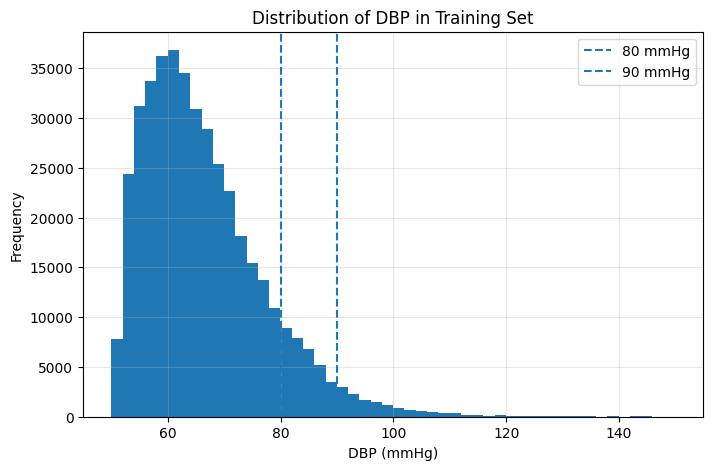

In [9]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(y_train, bins=50)

plt.axvline(80, linestyle="--", label="80 mmHg")
plt.axvline(90, linestyle="--", label="90 mmHg")

plt.xlabel("DBP (mmHg)")
plt.ylabel("Frequency")
plt.title("Distribution of DBP in Training Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## SIMPLE LINEAR REGRESSION ##

Simple Linear Regression
------------------------
Target: DBP
RMSE: 10.8096
MSE : 116.8468
R²  : 0.0669
MAE : 8.5372


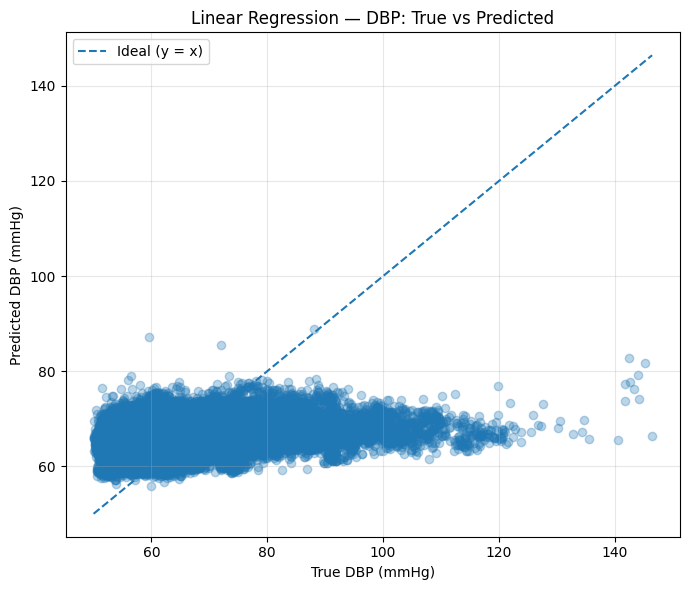

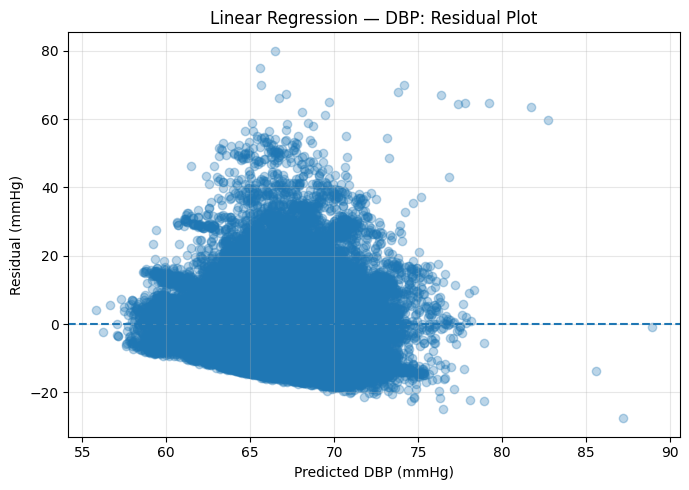

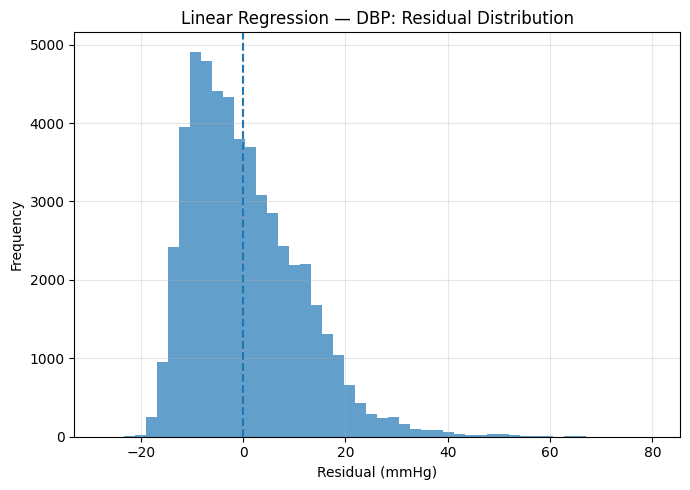

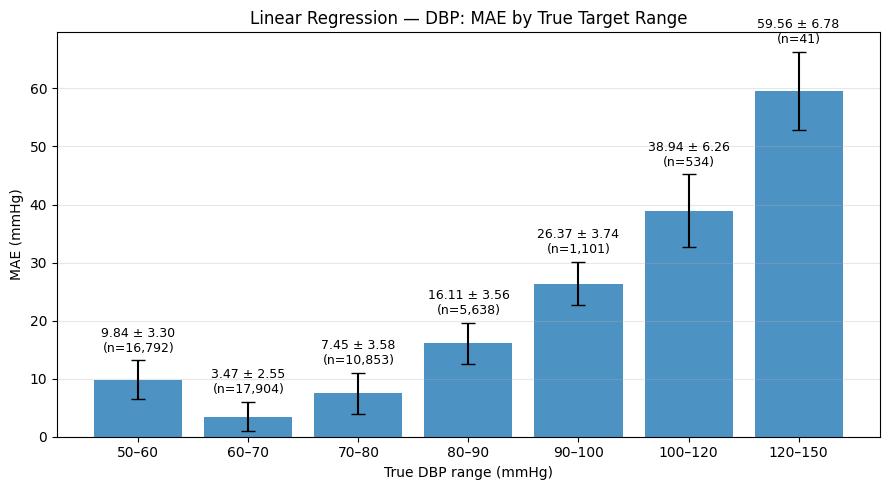

In [11]:
linear_model, y_test_pred = simple_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 41.9354
MSE : 1758.5810
R²  : -9.8043
MAE : 19.2226


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_0overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


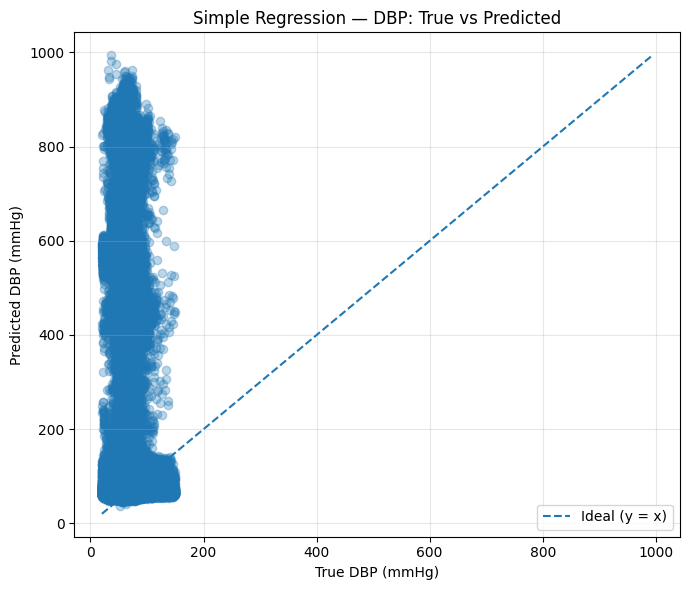

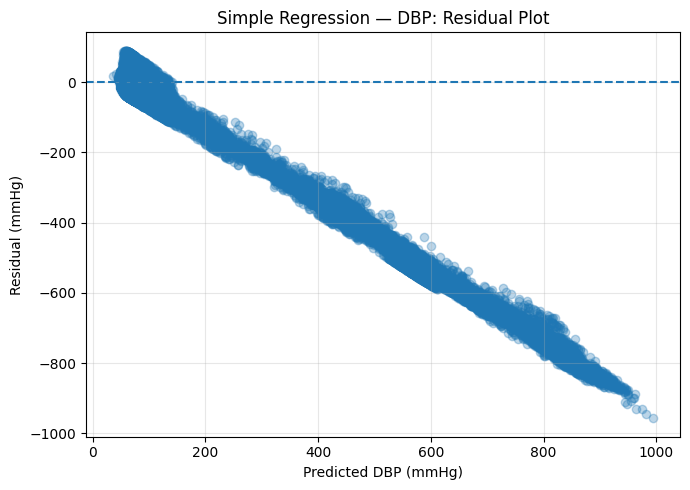

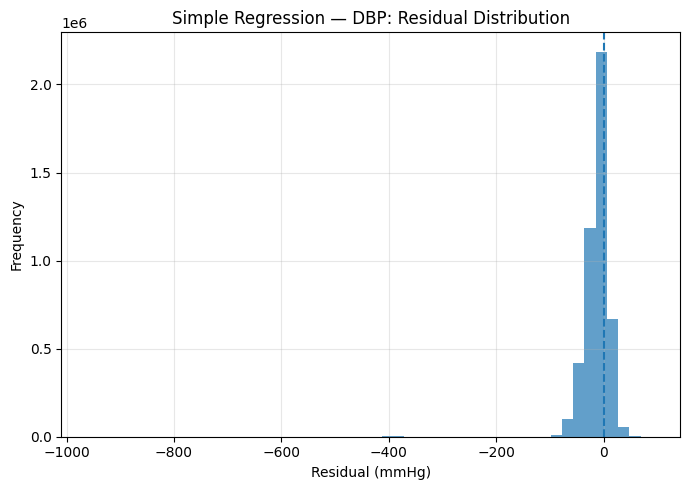

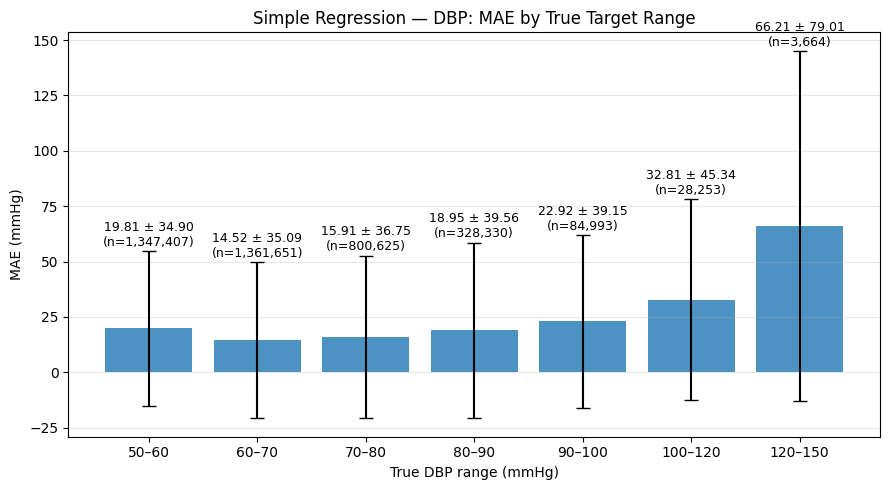

In [12]:
cross_gen(
    X_test_vital,
    y_test_vital,
    linear_model,
    "Simple Regression",
    TARGET
)

## INTERACTION LINEAR REGRESSION ##

Best parameters:
{'linear__fit_intercept': True}

Interaction Linear Regression — DBP
---------------------------------------------
RMSE: 10.4186
MSE : 108.5465
R²  : 0.1332
MAE : 8.1950


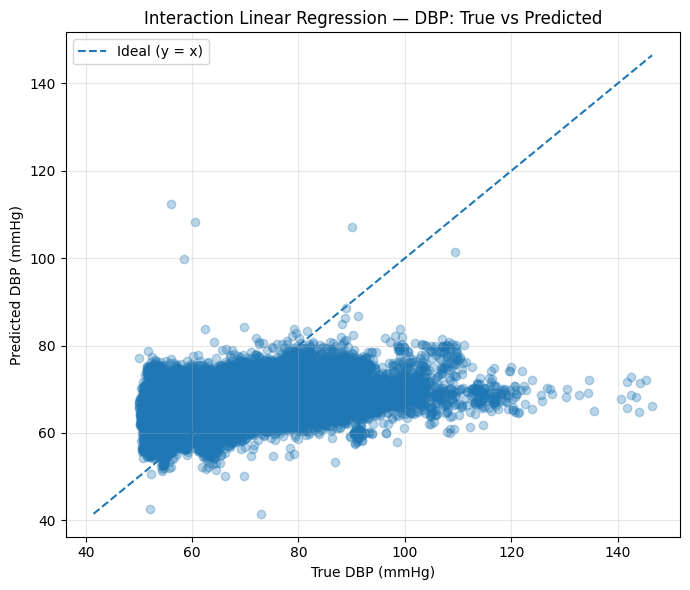

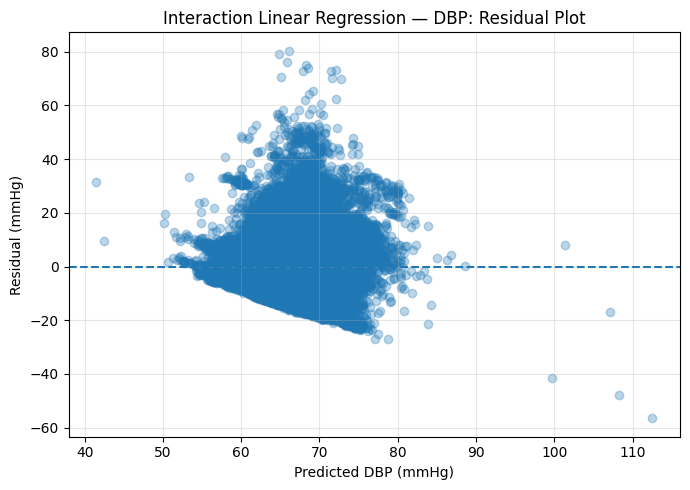

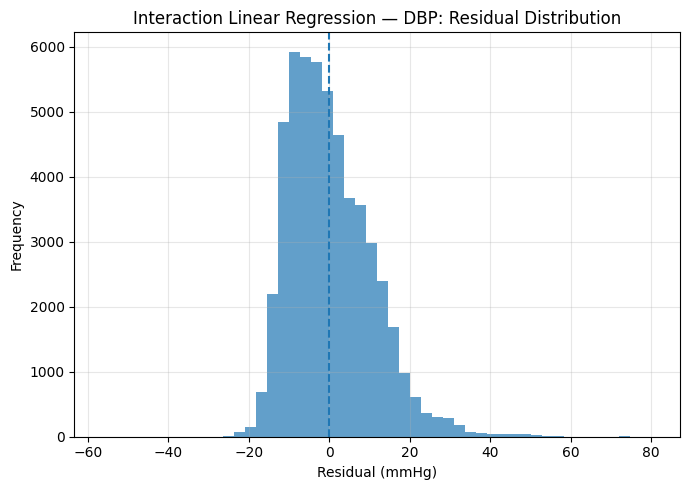

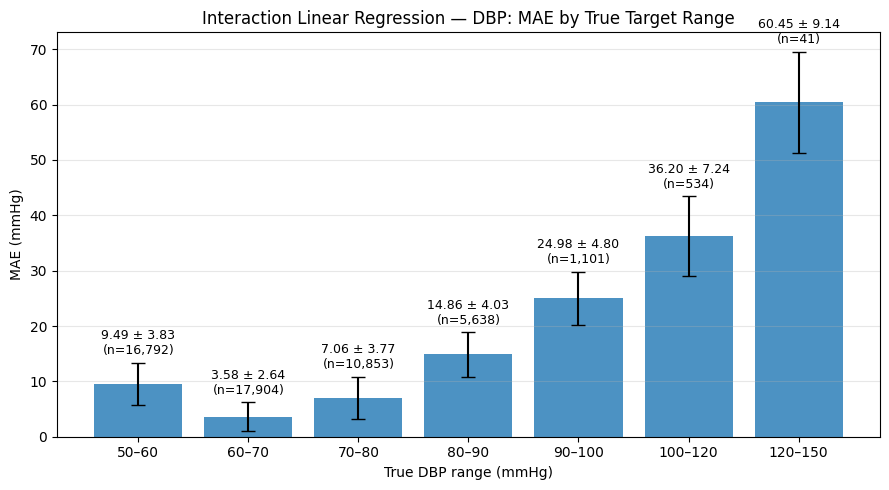

In [13]:
grid_interaction, y_test_pred = interaction_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 212.1606
MSE : 45012.1225
R²  : -275.5448
MAE : 58.9443


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_0overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


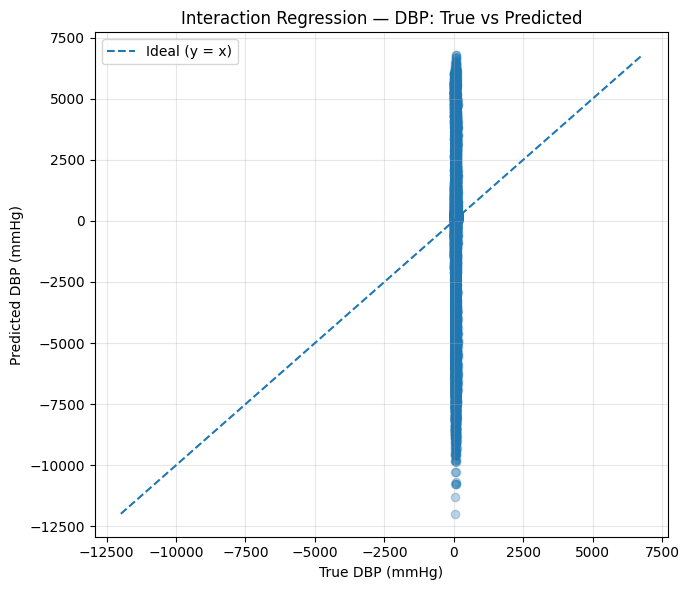

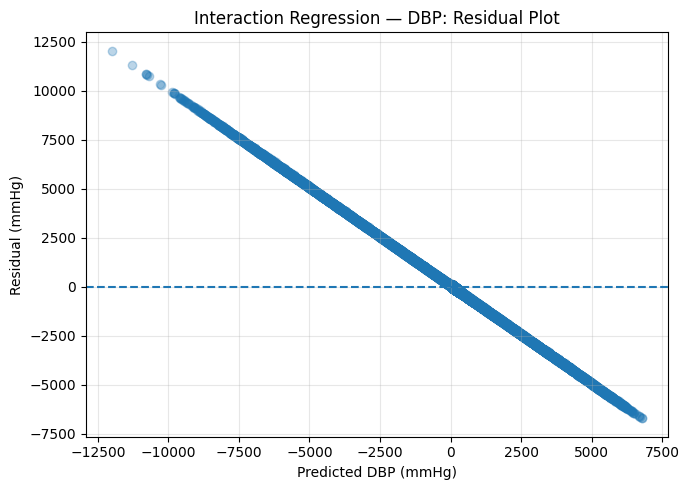

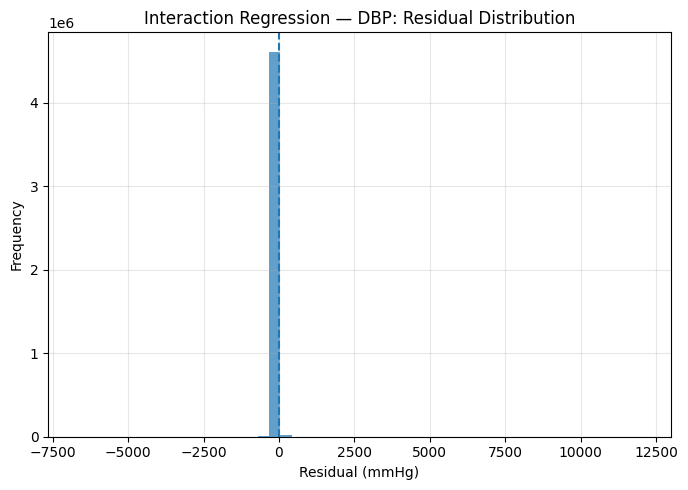

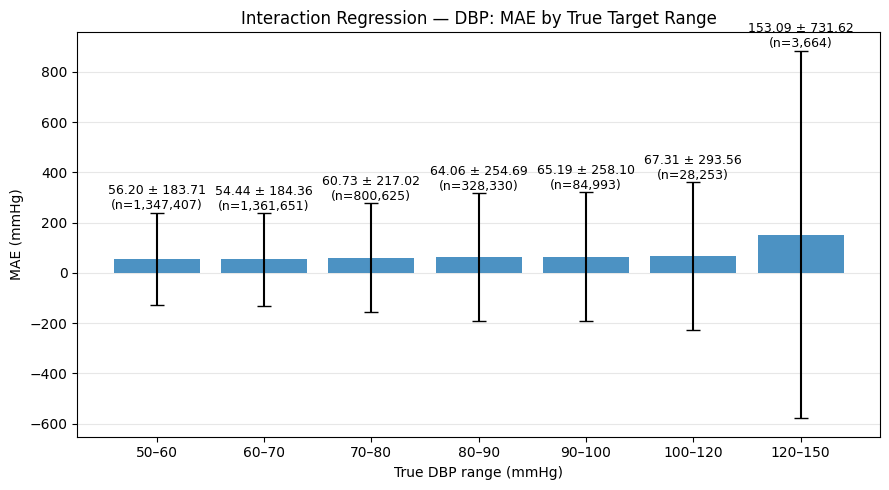

In [14]:
cross_gen(
    X_test_vital,
    y_test_vital,
    grid_interaction,
    "Interaction Regression",
    TARGET
)

## Robust Linear Regression ##

Best parameters:
{'alpha': 1.0, 'epsilon': 2.0}

Robust Linear Regression — DBP
----------------------------------------
RMSE: 10.8360
MSE : 117.4187
R²  : 0.0623
MAE : 8.4805


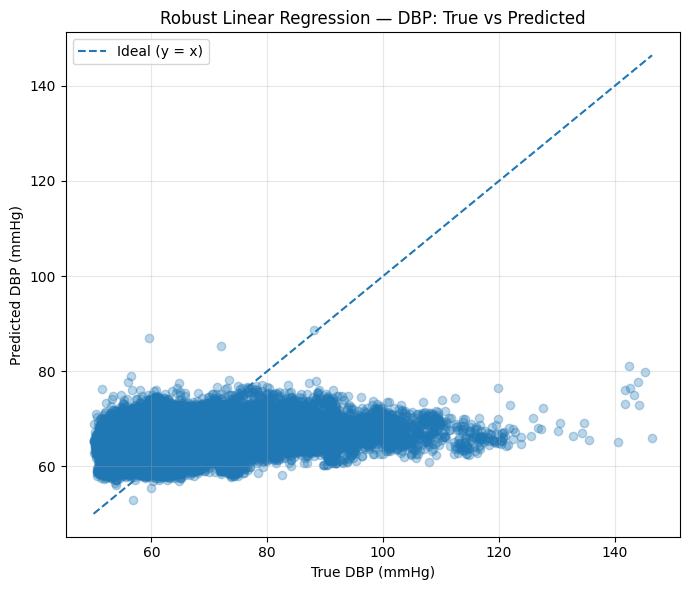

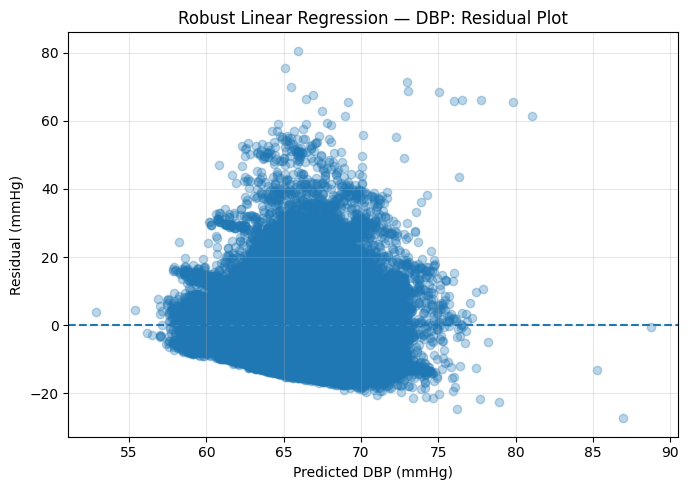

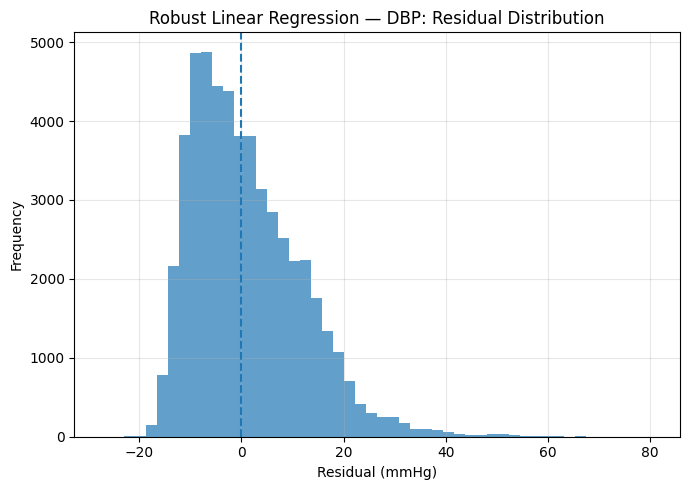

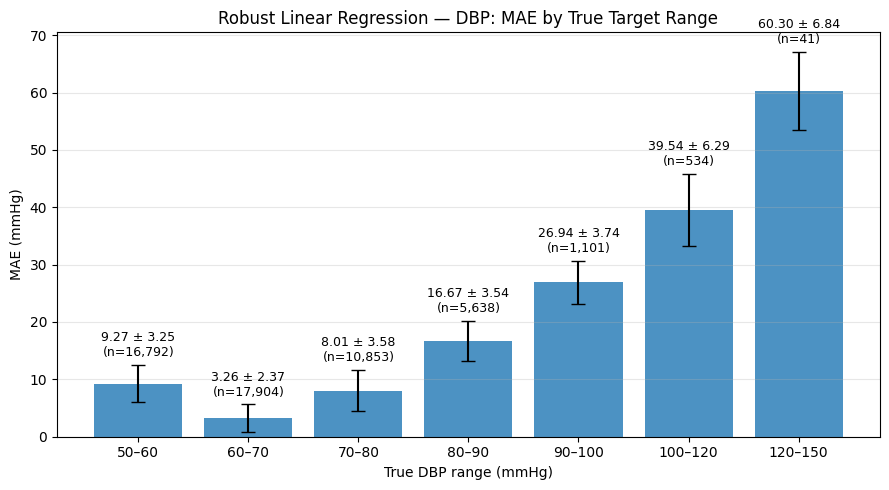

In [15]:
huber_model, y_test_pred = huber_regression(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 44.5015
MSE : 1980.3875
R²  : -11.1671
MAE : 20.9037


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_0overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


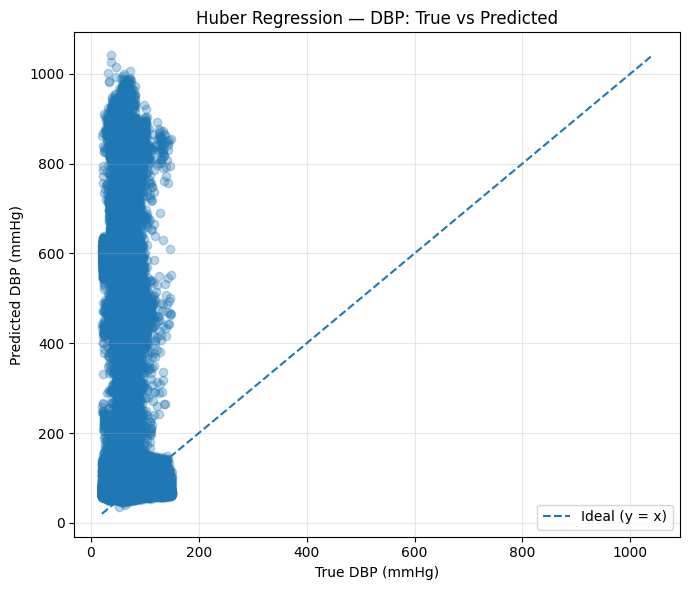

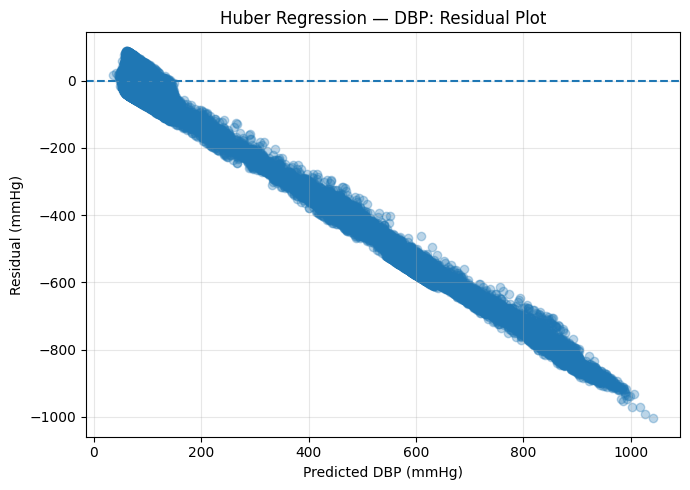

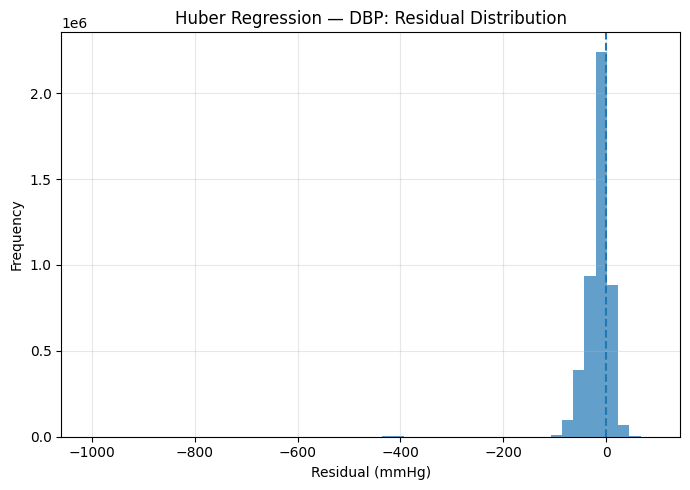

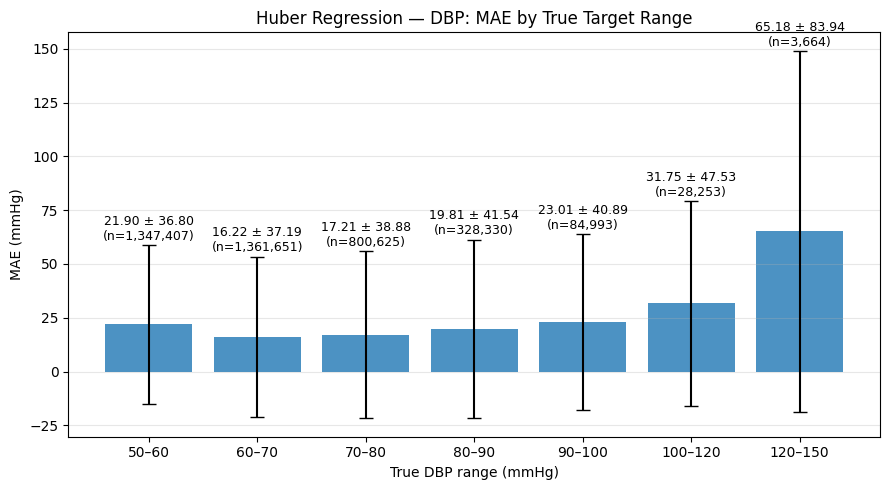

In [16]:
cross_gen(
    X_test_vital,
    y_test_vital,
    huber_model,
    "Huber Regression",
    TARGET
)

## Fine Decision Tree ##

Best parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Fine Decision Tree — DBP
--------------------------------
RMSE: 10.4235
MSE : 108.6489
R²  : 0.1324
MAE : 7.9509


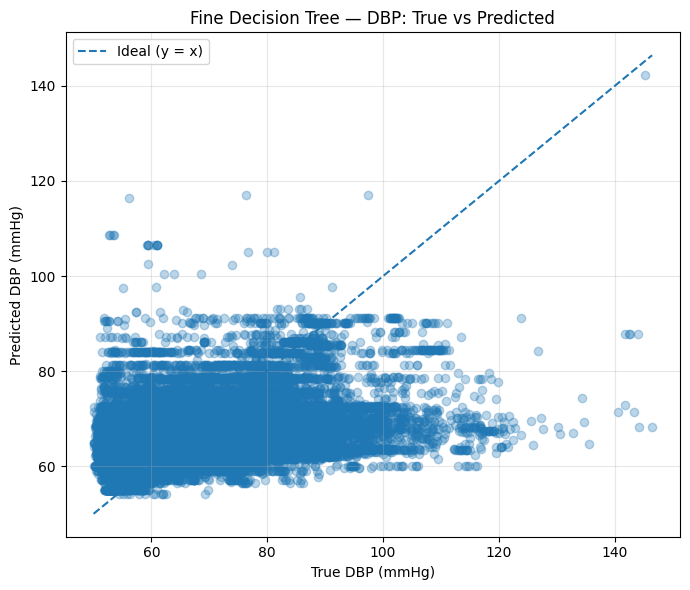

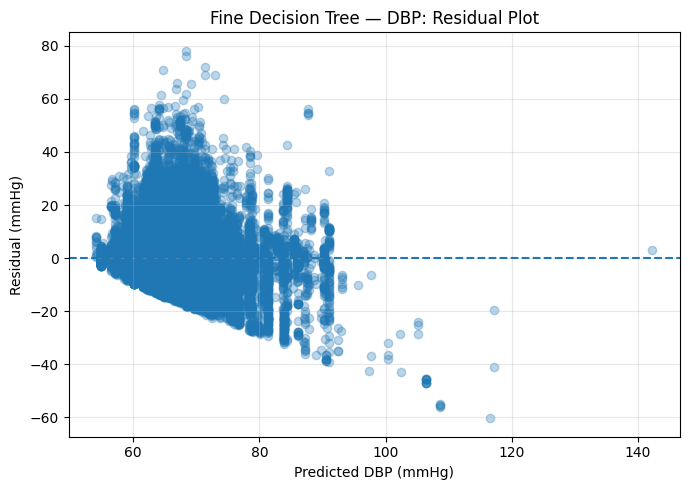

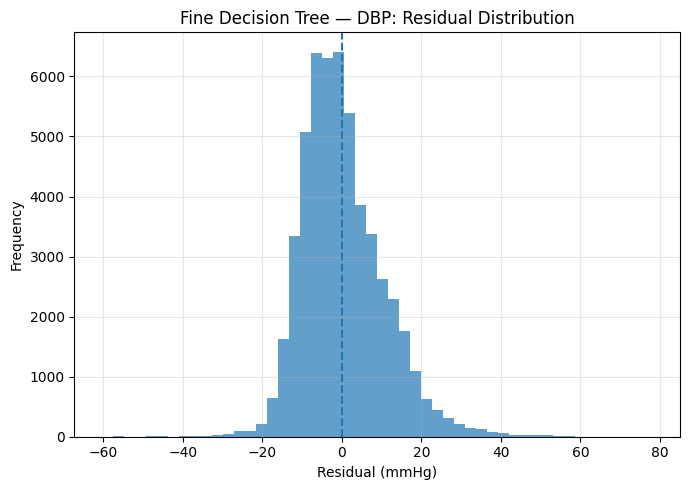

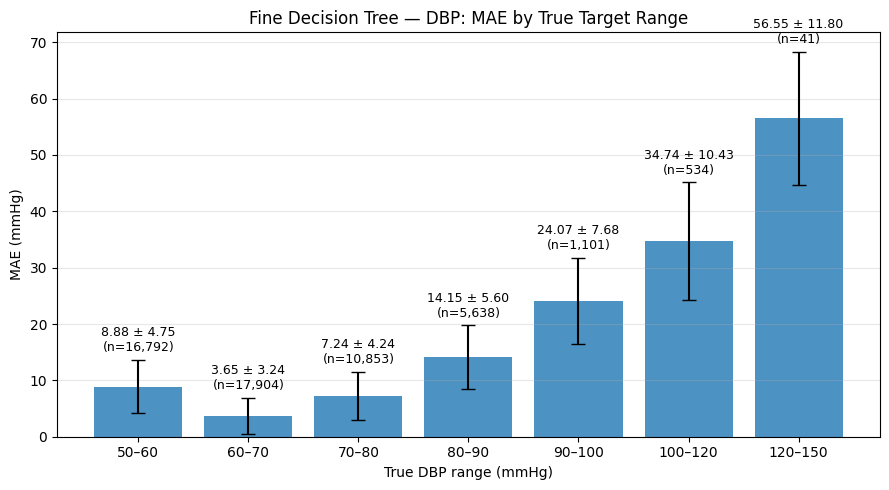

In [17]:
tree_model, y_test_pred = decision_tree(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)


RMSE: 17.9182
MSE : 321.0611
R²  : -0.9725
MAE : 14.1635


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_0overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


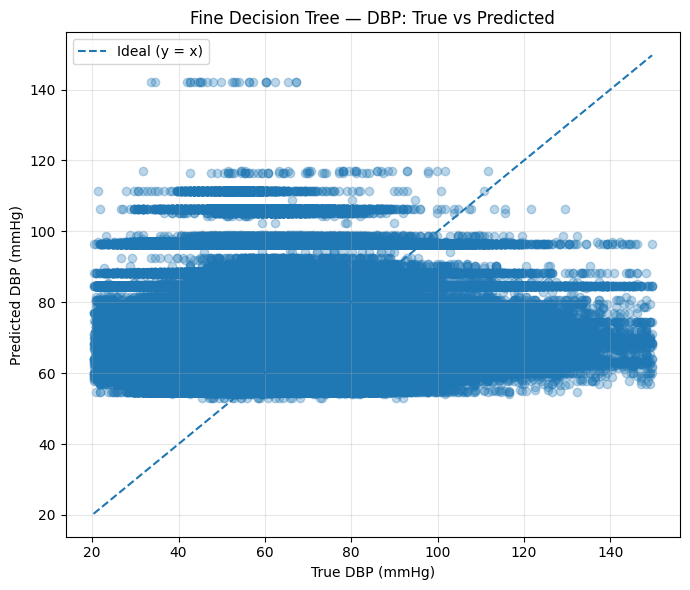

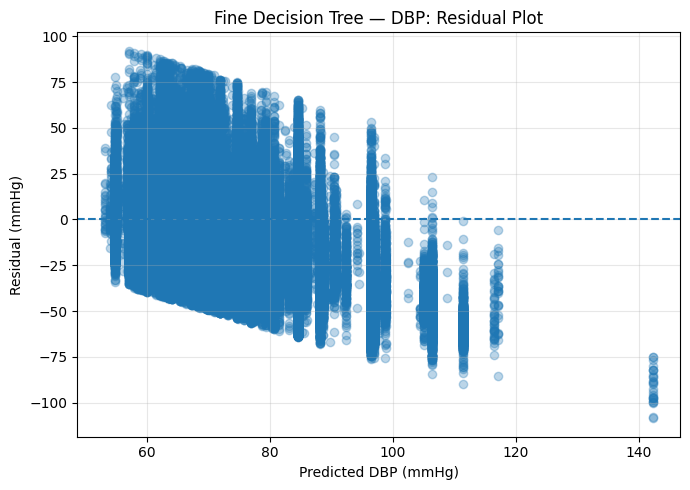

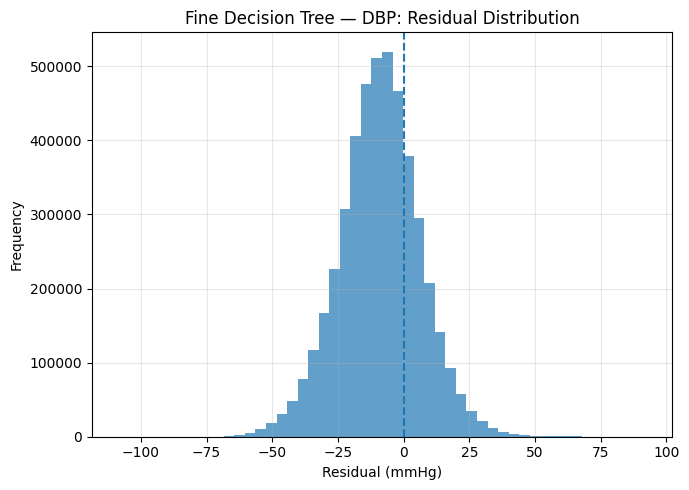

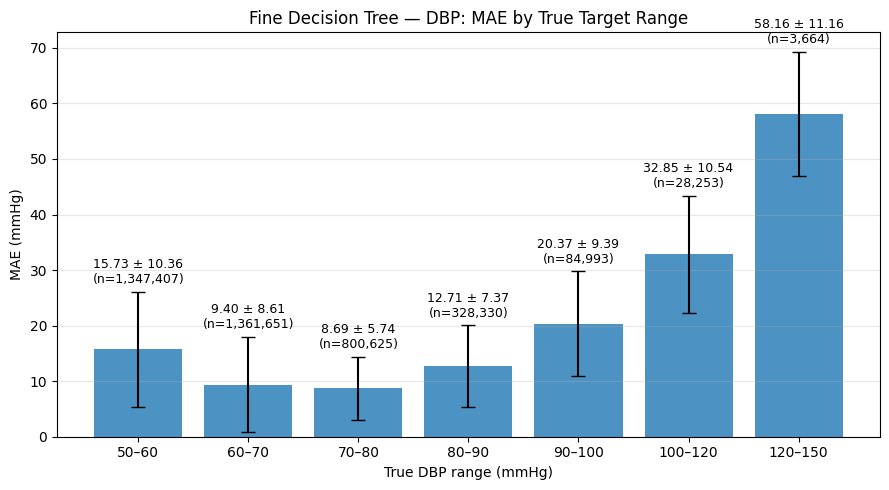

In [18]:
cross_gen(
    X_test_vital,
    y_test_vital,
    tree_model,
    "Fine Decision Tree",
    TARGET
)

## Random Forest ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest — DBP
----------------------------
RMSE: 9.2600
MSE : 85.7481
R²  : 0.3152
MAE : 6.9055


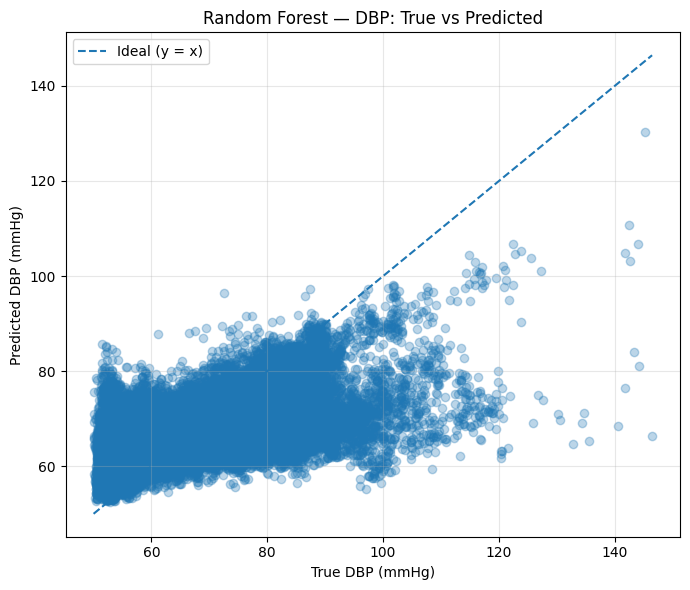

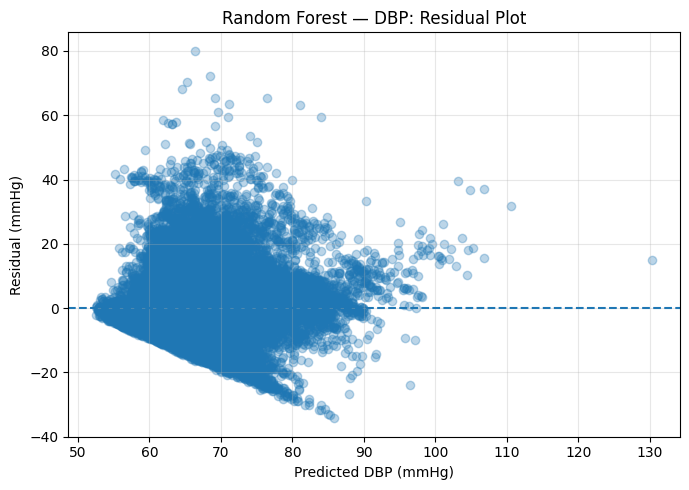

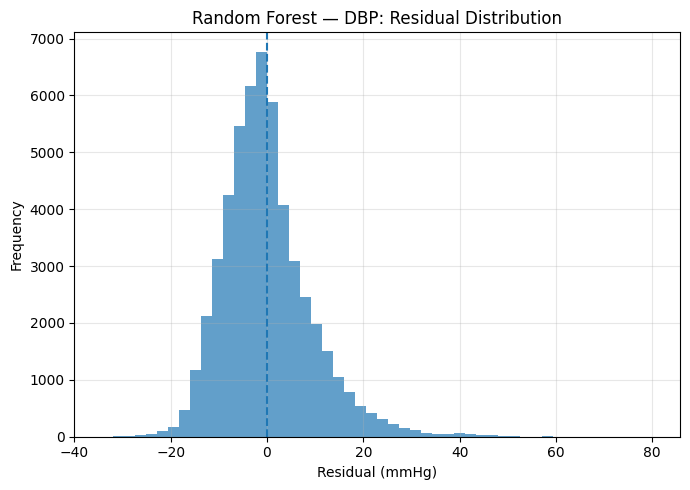

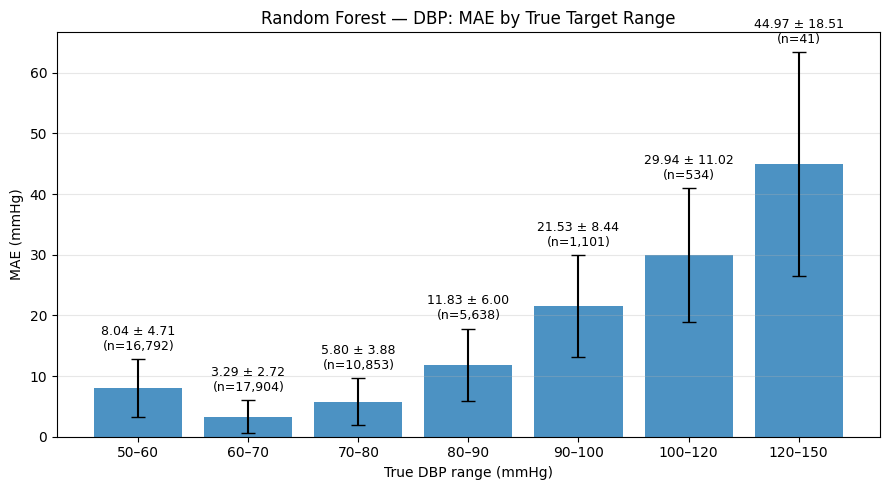

In [19]:
rf_model, y_test_pred = random_forest(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 16.9786
MSE : 288.2732
R²  : -0.7711
MAE : 14.0177


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_0overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


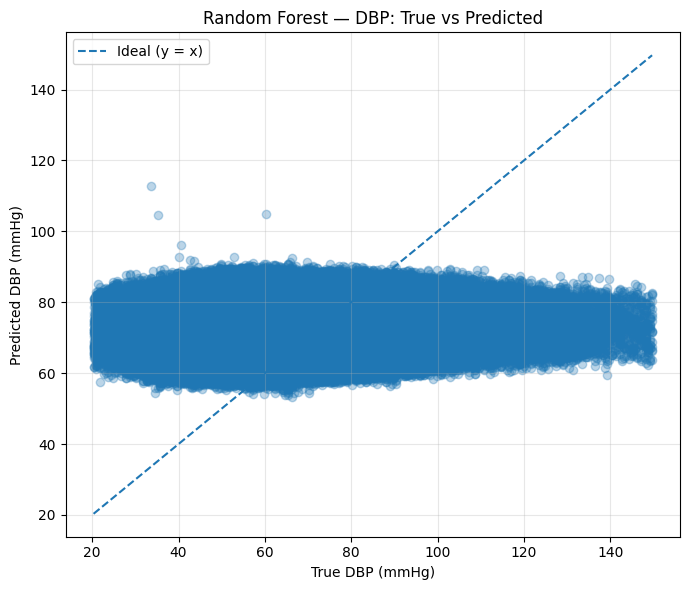

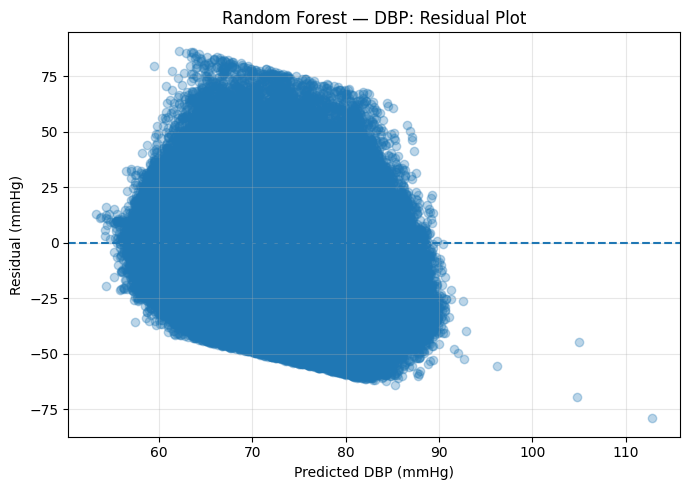

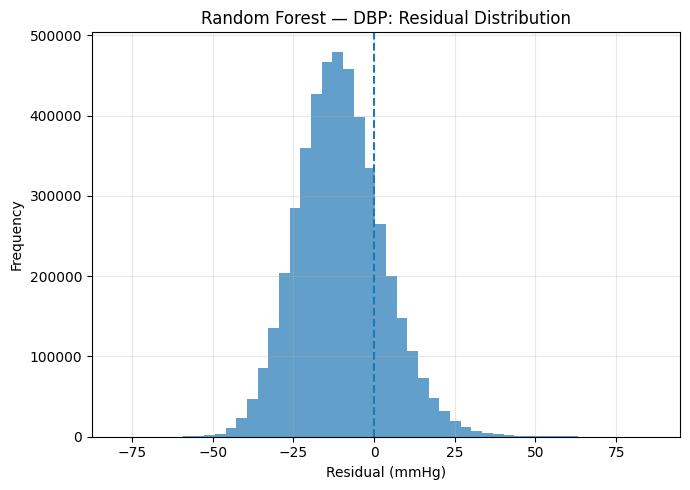

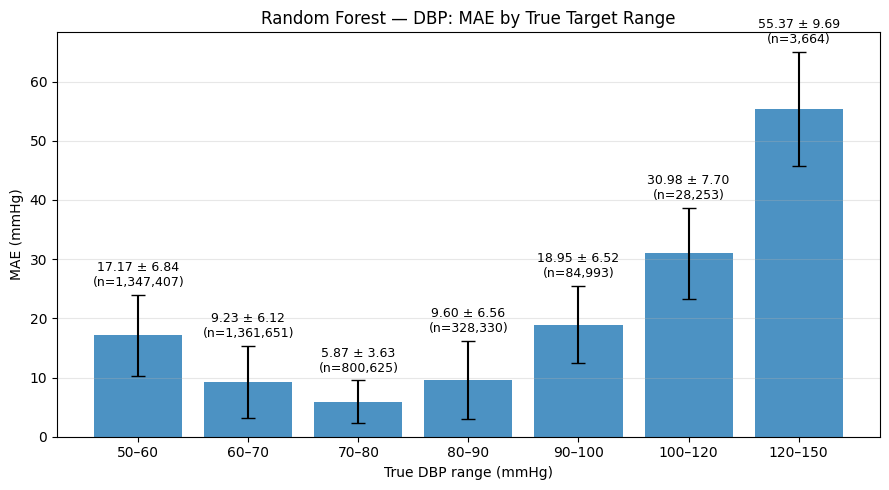

In [20]:
cross_gen(
    X_test_vital,
    y_test_vital,
    rf_model,
    "Random Forest",
    TARGET
)

## Extra TREES ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Extra Trees Regressor — DBP
--------------------------------------
RMSE: 9.1775
MSE : 84.2263
R²  : 0.3274
MAE : 6.7637


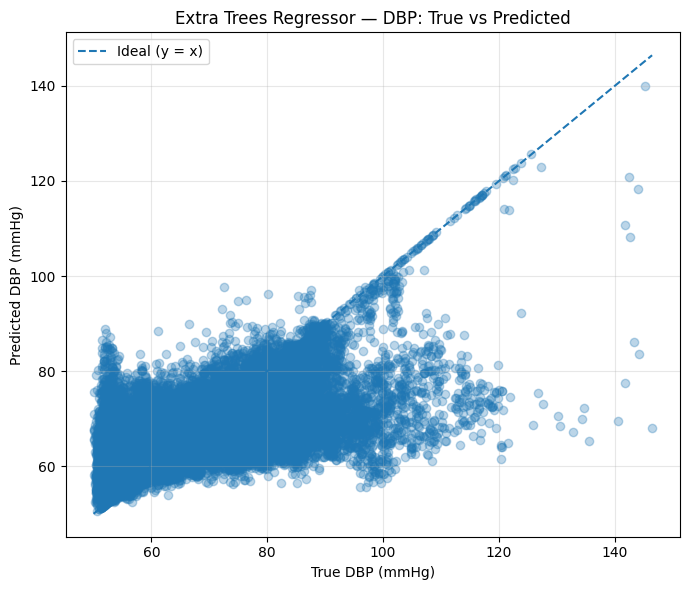

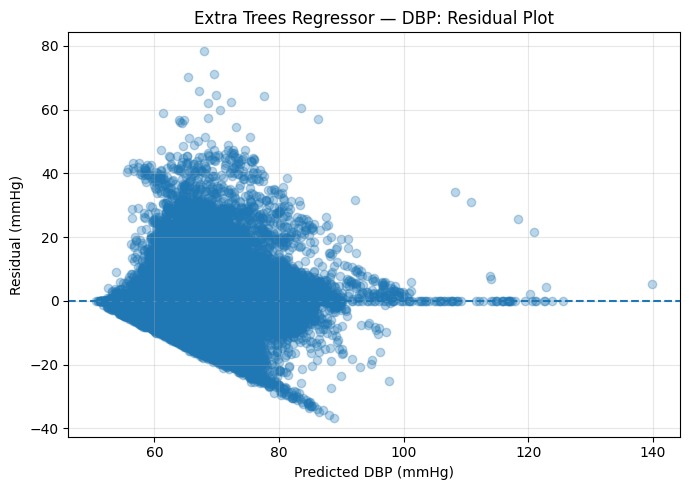

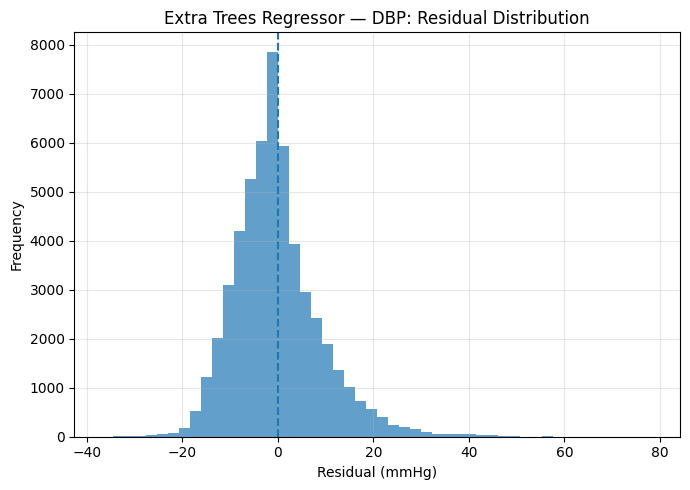

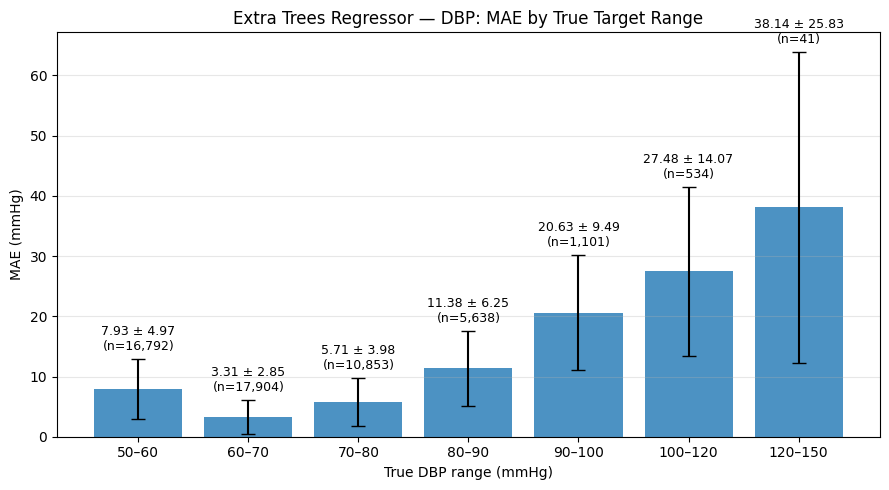

In [21]:
extra_trees_model, y_test_pred = extra_trees(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 17.1252
MSE : 293.2736
R²  : -0.8018
MAE : 14.1231


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_0overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


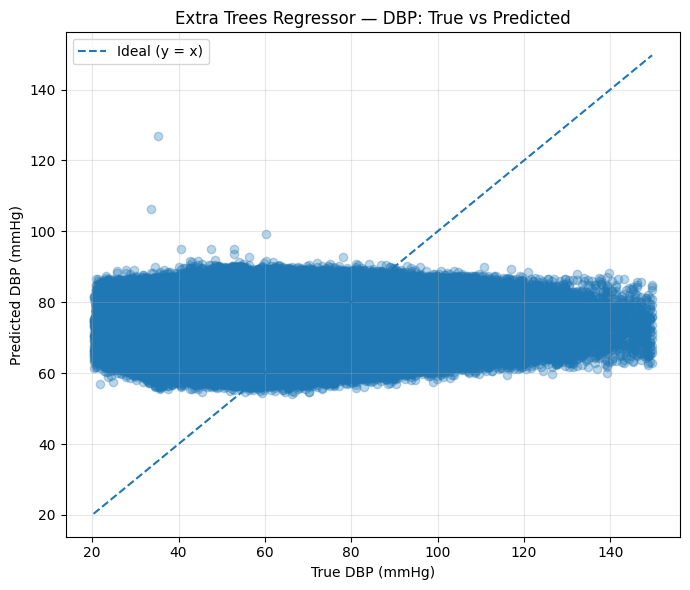

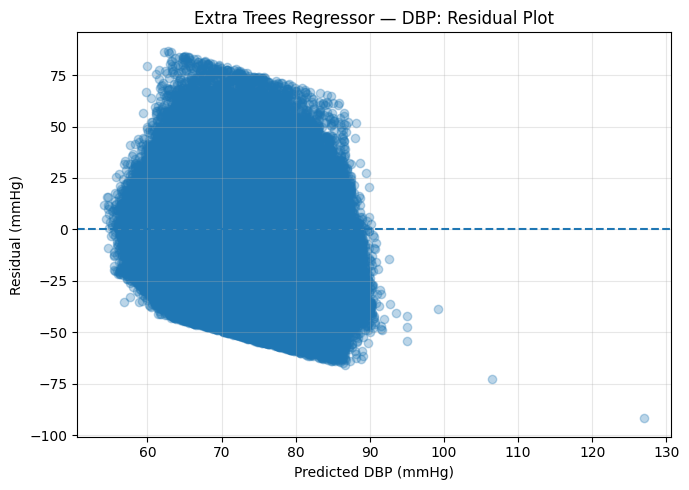

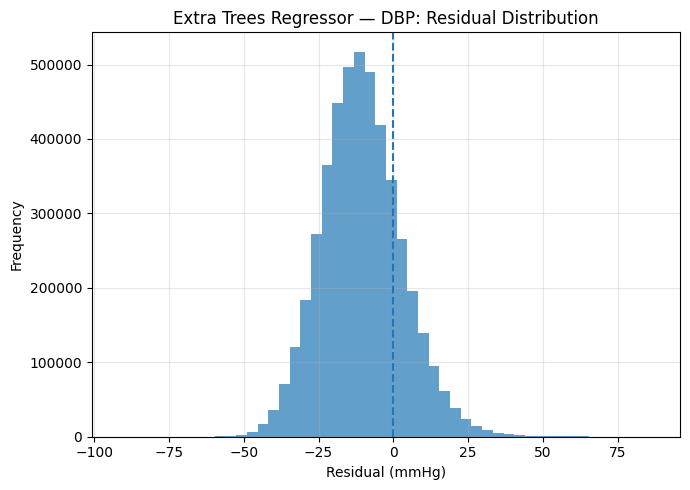

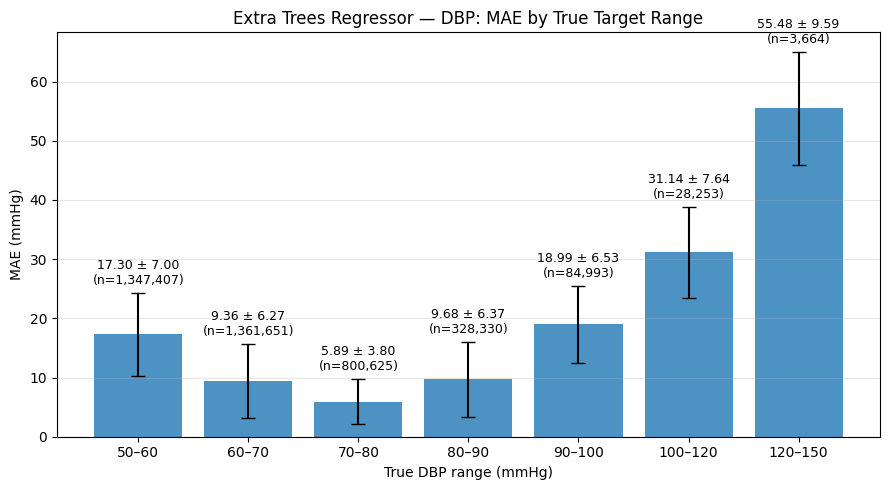

In [22]:
cross_gen(
    X_test_vital,
    y_test_vital,
    extra_trees_model,
    "Extra Trees Regressor",
    TARGET
)

## XGBOOST ##

Best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

XGBoost — DBP
---------------------
RMSE: 9.7432
MSE : 94.9299
R²  : 0.2419
MAE : 7.3831


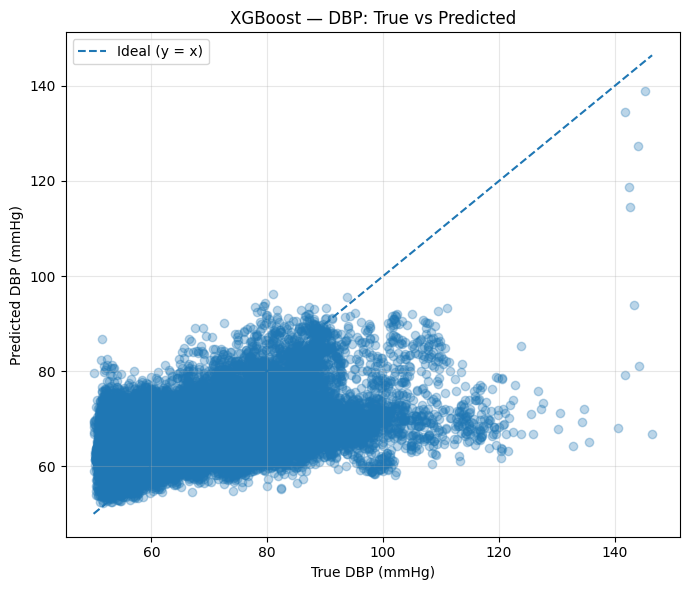

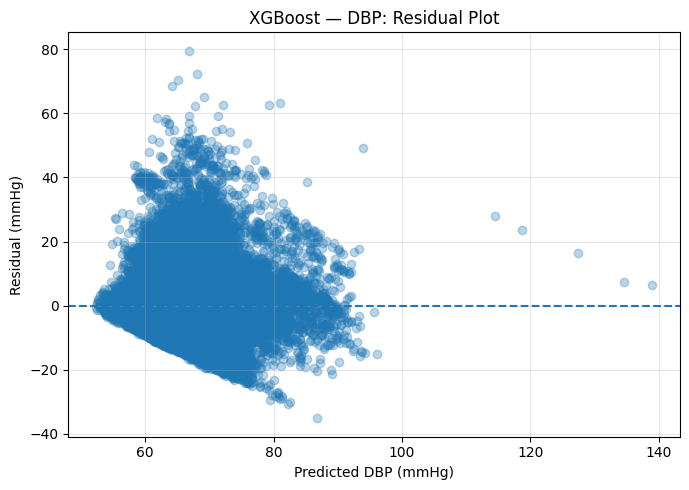

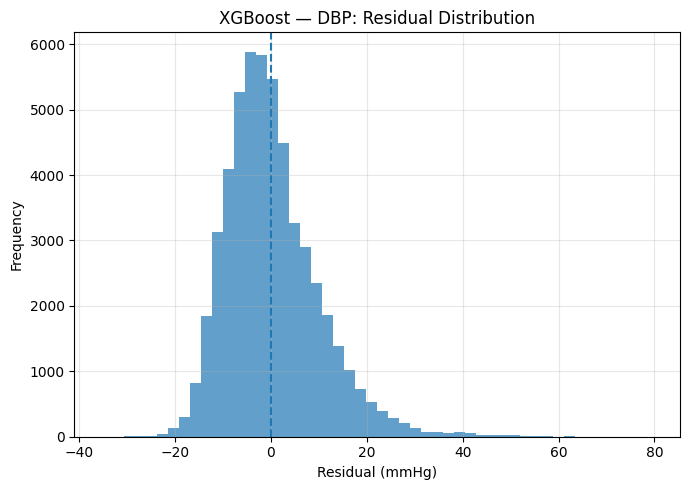

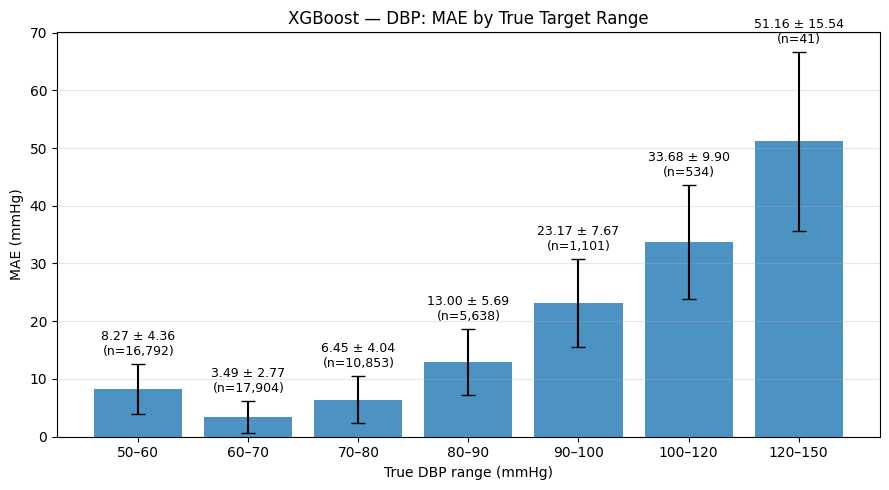

In [23]:
xgbmodel, y_test_pred = xgboost_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 19.3064
MSE : 372.7382
R²  : -1.2900
MAE : 15.4162


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_0overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


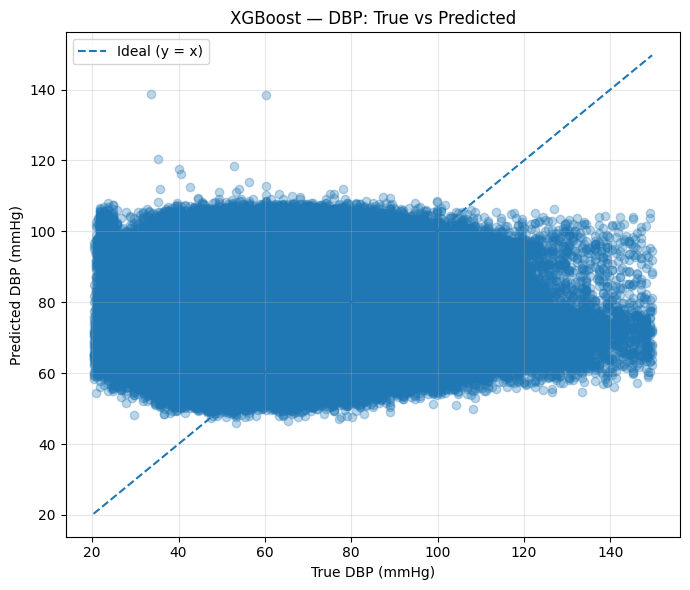

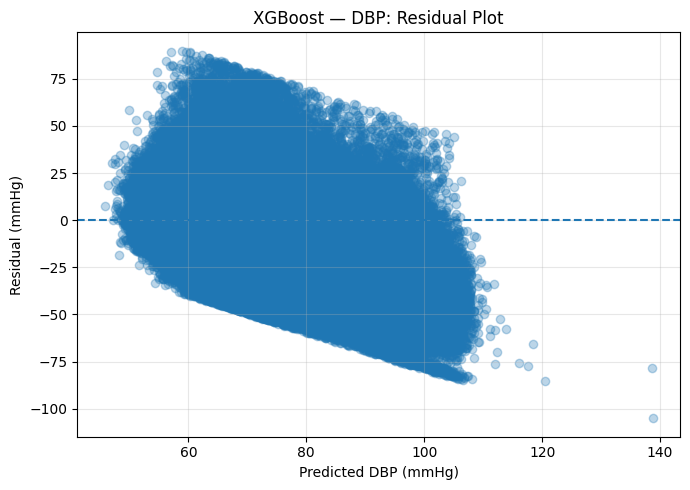

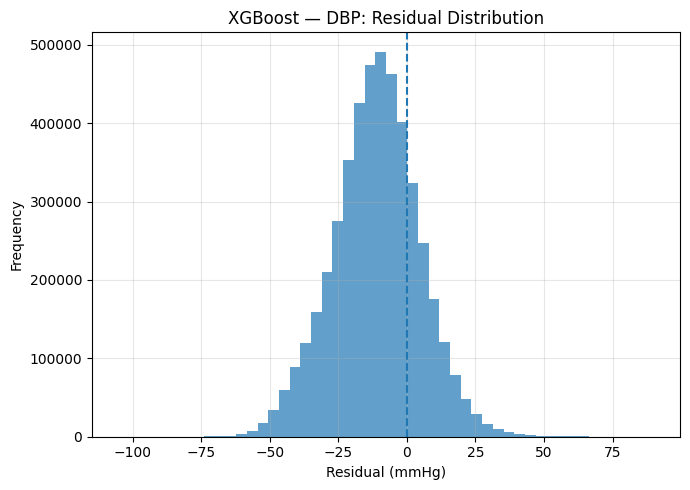

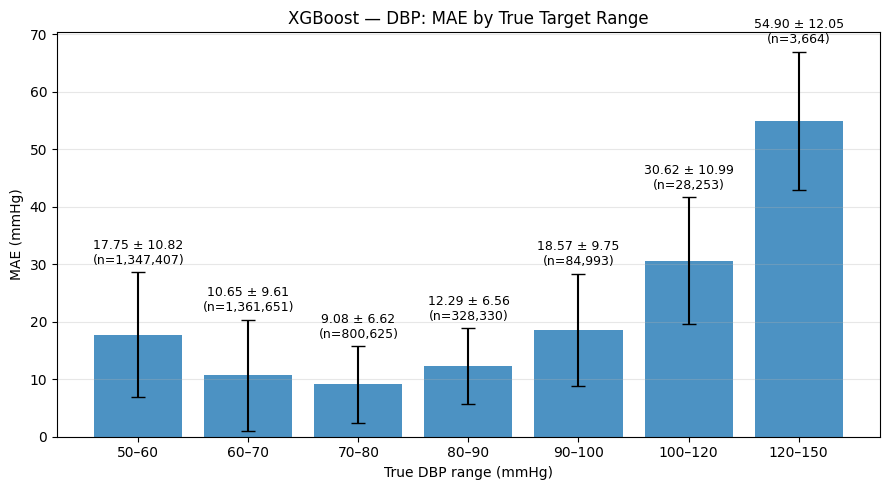

In [24]:
cross_gen(
    X_test_vital,
    y_test_vital,
    xgbmodel,
    "XGBoost",
    TARGET
)

## Light GBM ##

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   6.1s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time= 1.9min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time= 4.4min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time= 4.5min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time= 4.7min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time= 5.2min
[CV] END learning_rate=0.05, max_depth=10, n_estimators=100, num_leaves=15; total time=  16.5s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=31; total time= 3.8min
[CV] END learning_rate=0.05, max_depth=10, n_estimators=100, num_leaves=15; total time= 1.0min
[CV] END learning_rate=0.05, max_depth=10, n_estimators=100, num_leaves=31; total ti

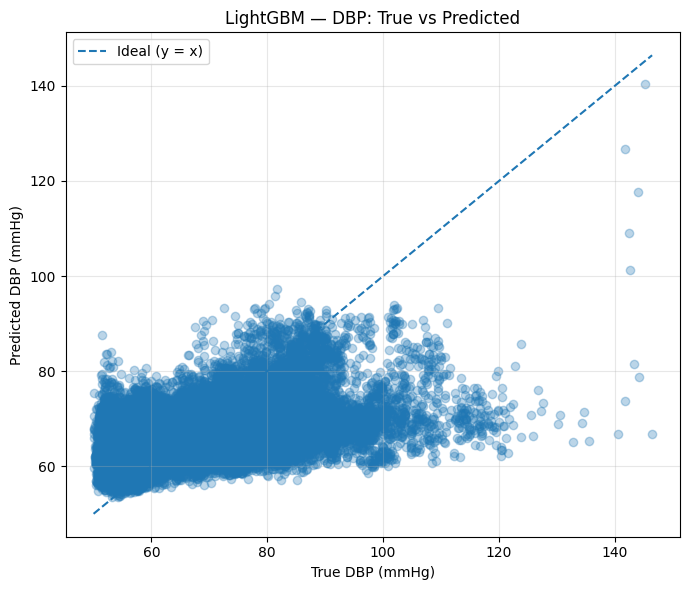

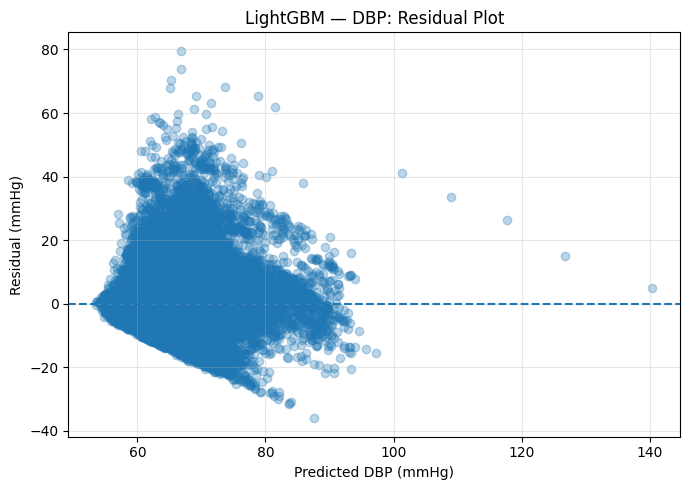

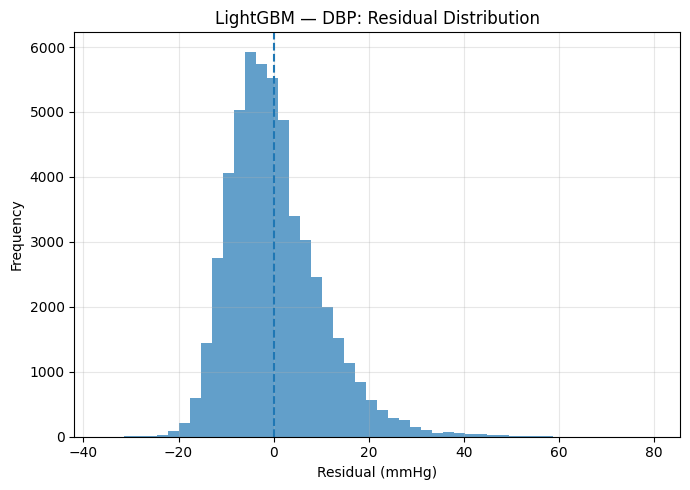

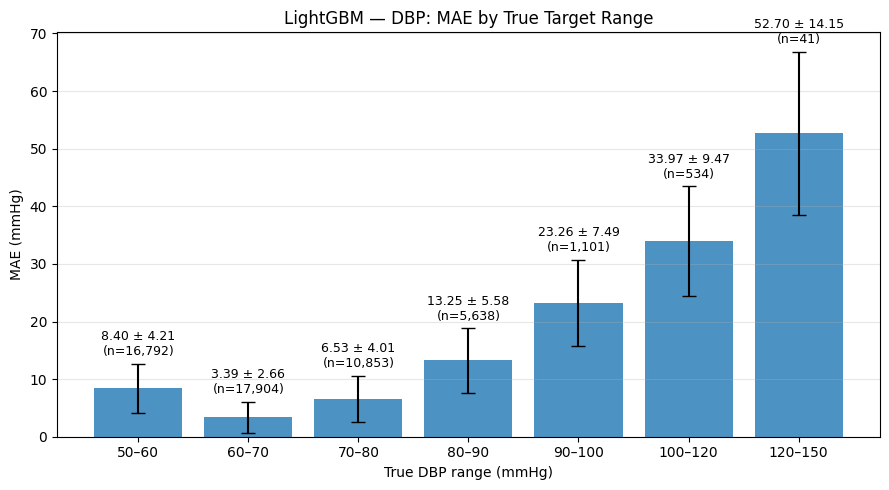

In [25]:
lgbmmodel, y_test_pred = lightgbm_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 16.3007
MSE : 265.7139
R²  : -0.6325
MAE : 13.2583


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_0overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


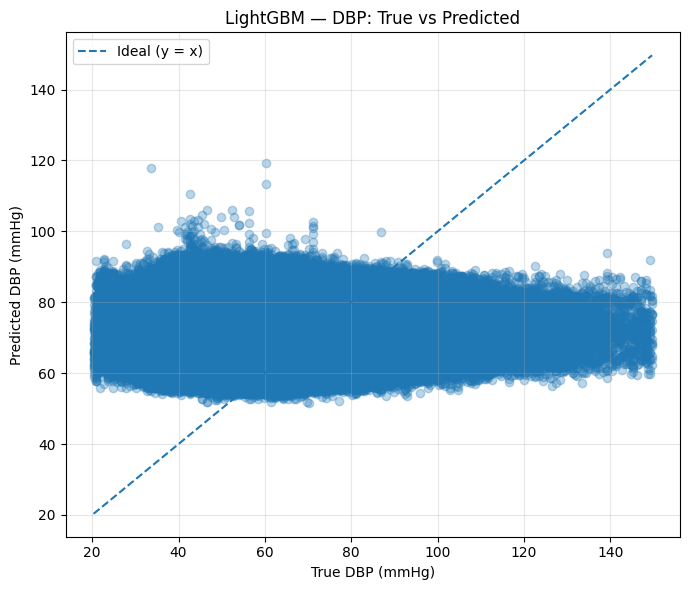

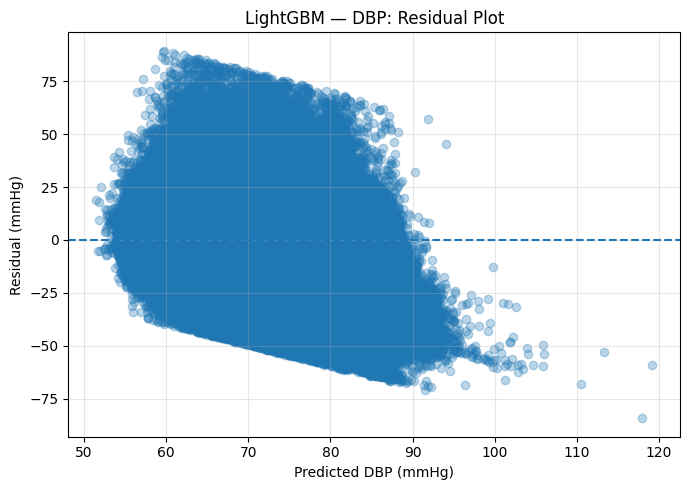

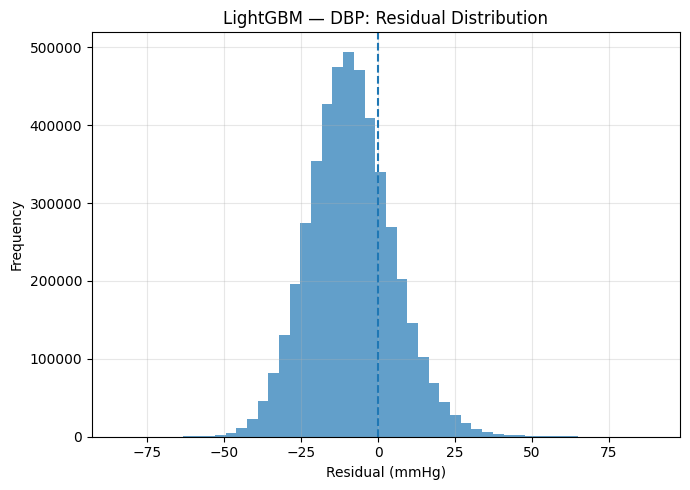

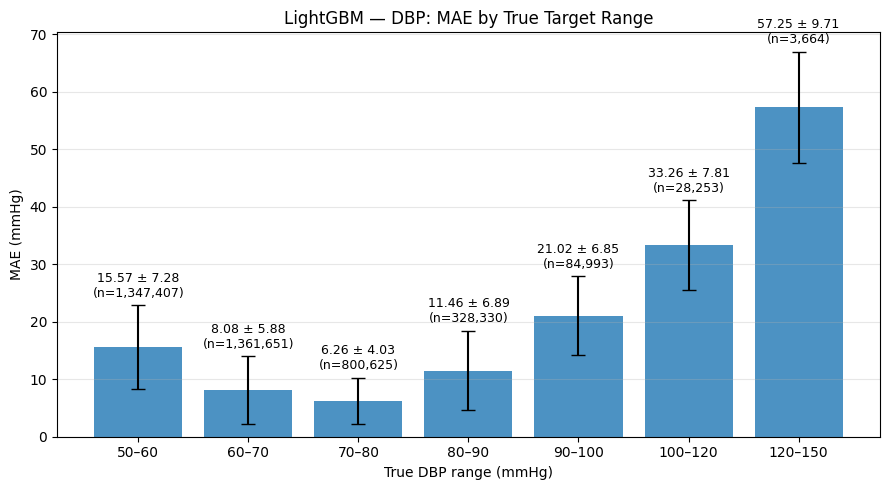

In [26]:
cross_gen(
    X_test_vital,
    y_test_vital,
    lgbmmodel,
    "LightGBM",
    TARGET
)

##  Matern 5/2 gpr ##

Best parameters:
{'kernel': 1**2 * Matern(length_scale=0.5, nu=2.5) + WhiteKernel(noise_level=1)}

Matern 5/2 GPR — DBP
--------------------------------
RMSE: 10.1943
MSE : 103.9244
R²  : 0.1701
MAE : 7.8263


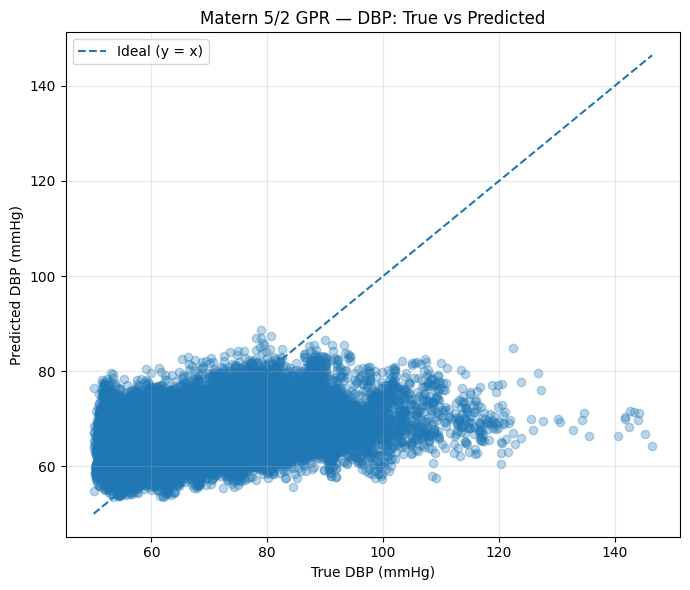

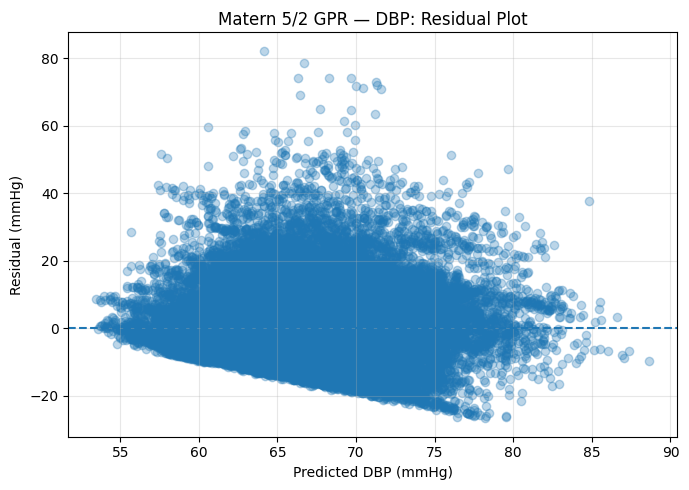

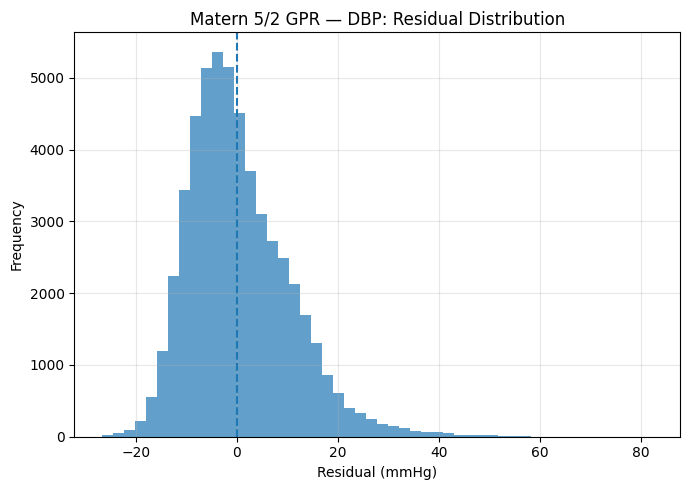

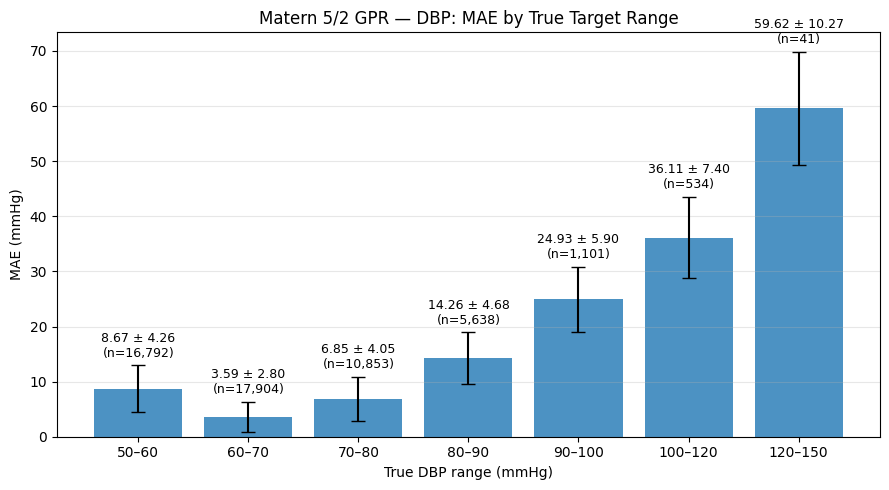

In [10]:
gpr_model, y_test_pred = gpr_matern(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 13.2050
MSE : 174.3719
R²  : -0.0713
MAE : 10.5857


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_0overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


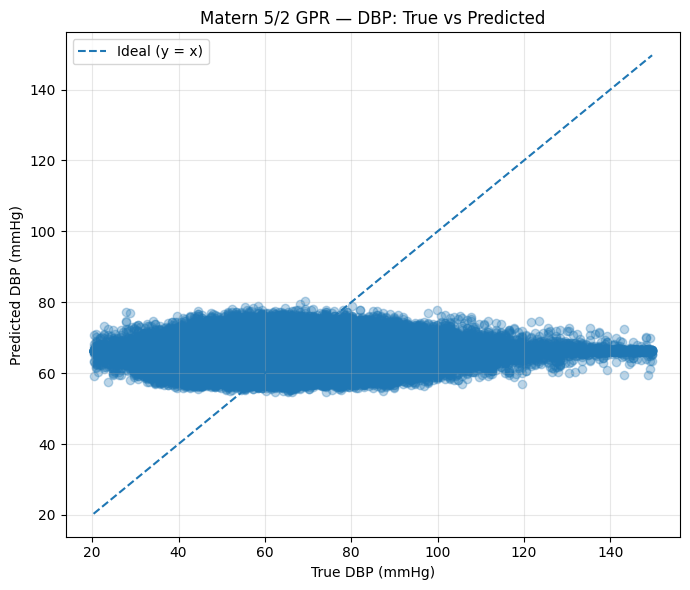

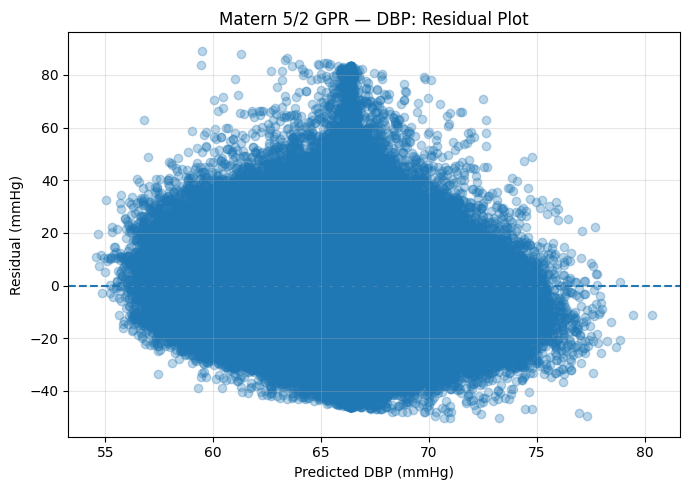

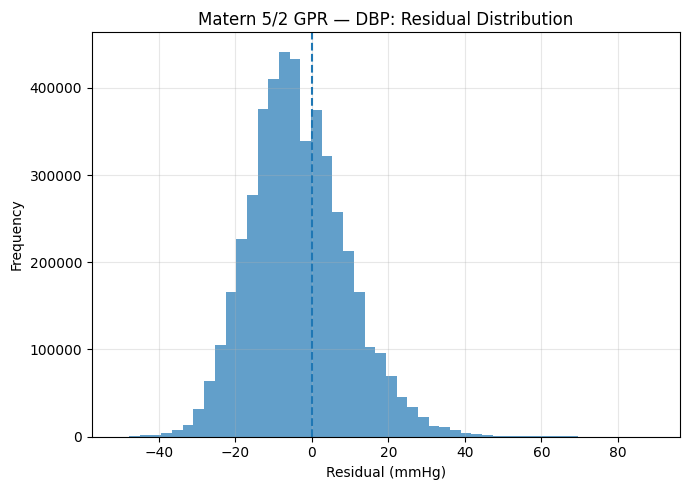

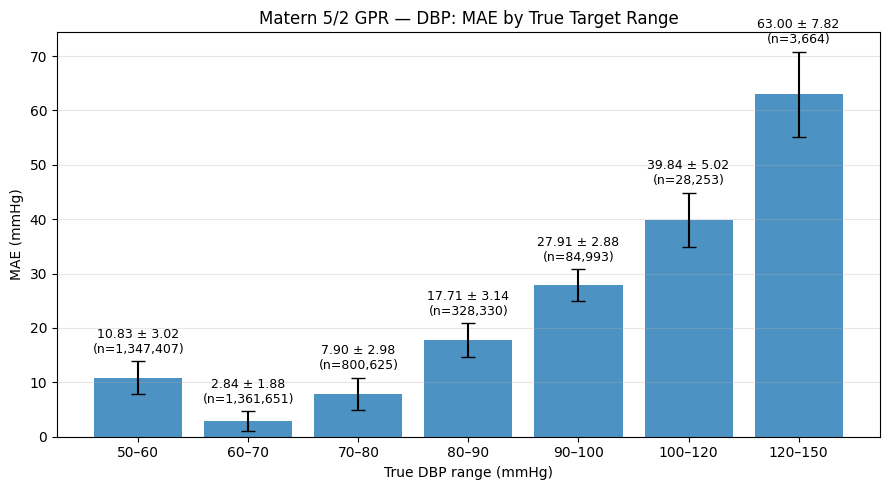

In [11]:
y_pred_vitaldb = predict_gpr_in_batches(
    model=gpr_model,
    X=X_test_vital,
    y_test=y_test_vital,
    target_name=TARGET,
    model_name="Matern 5/2 GPR",
    batch_size=10000
)

## Rational Quadratic GPR ##

GPR training samples: 5,000

Starting Rational Quadratic GPR GridSearch...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a bette


Best parameters:
{'kernel': 1**2 * RationalQuadratic(alpha=1, length_scale=2) + WhiteKernel(noise_level=1)}

Best CV RMSE: 9.590299332053709

Best GPR model:
GaussianProcessRegressor(kernel=1**2 * RationalQuadratic(alpha=1, length_scale=2) + WhiteKernel(noise_level=1),
                         normalize_y=True, random_state=42)

Starting batched prediction on 52,863 samples...
RMSE: 10.2398
MSE : 104.8530
R²  : 0.1627
MAE : 7.8472


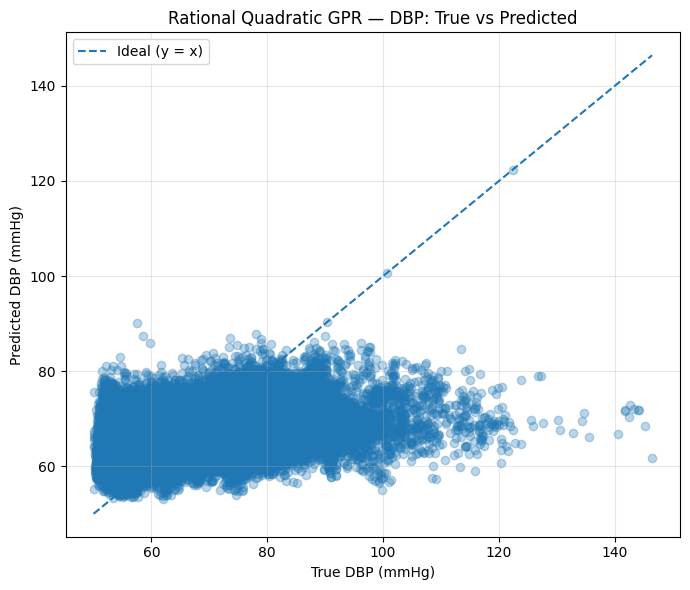

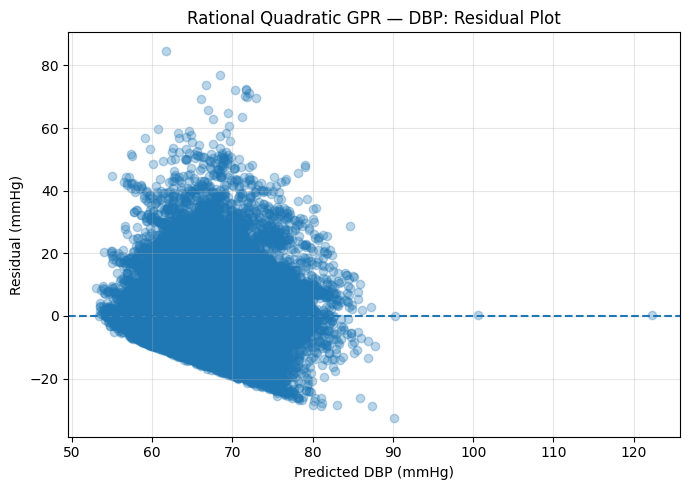

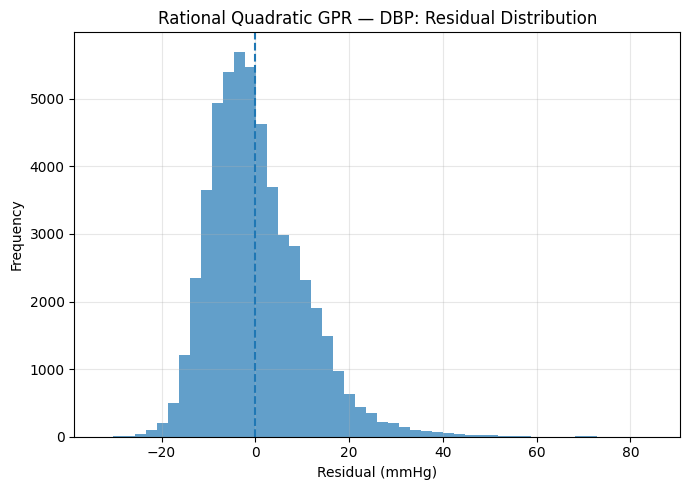

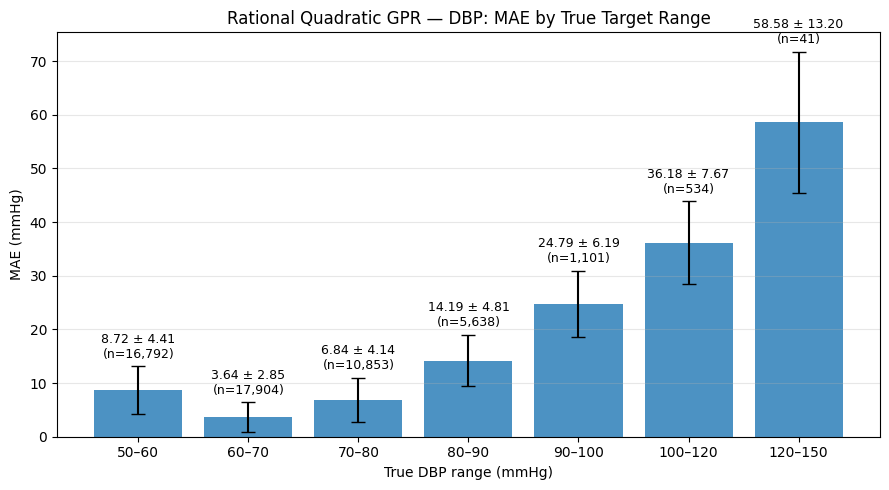

In [12]:
rq_model, y_test_pred = gpr_rational_quadratic(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 13.1632
MSE : 173.2695
R²  : -0.0645
MAE : 10.5429


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_0overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


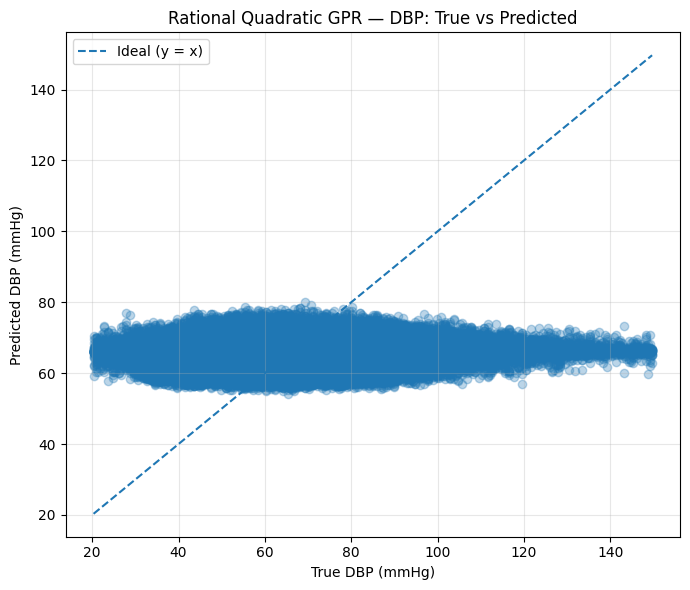

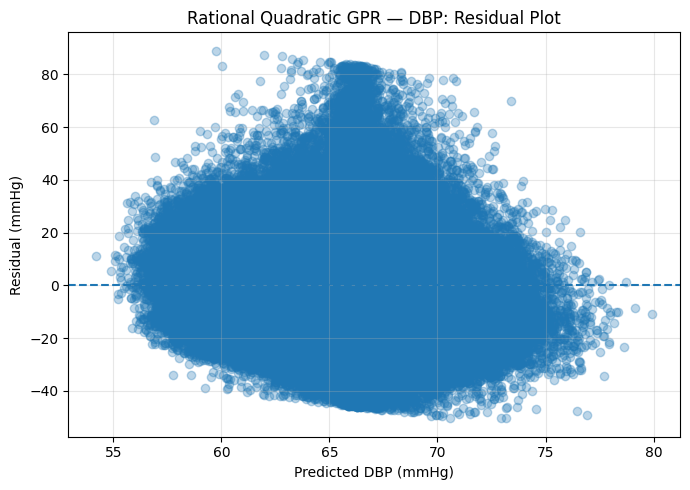

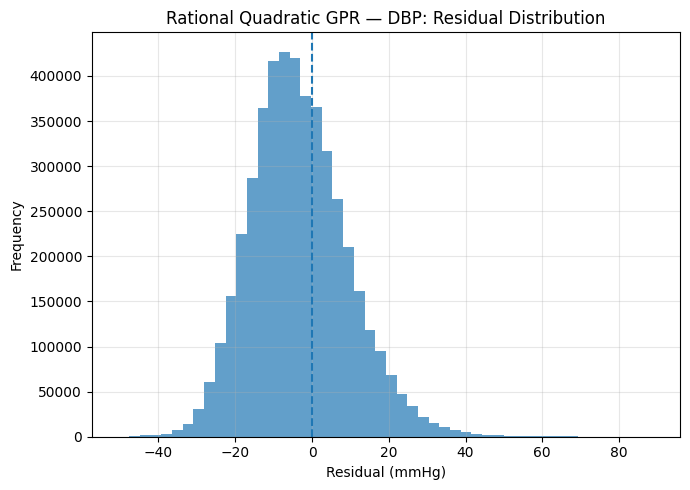

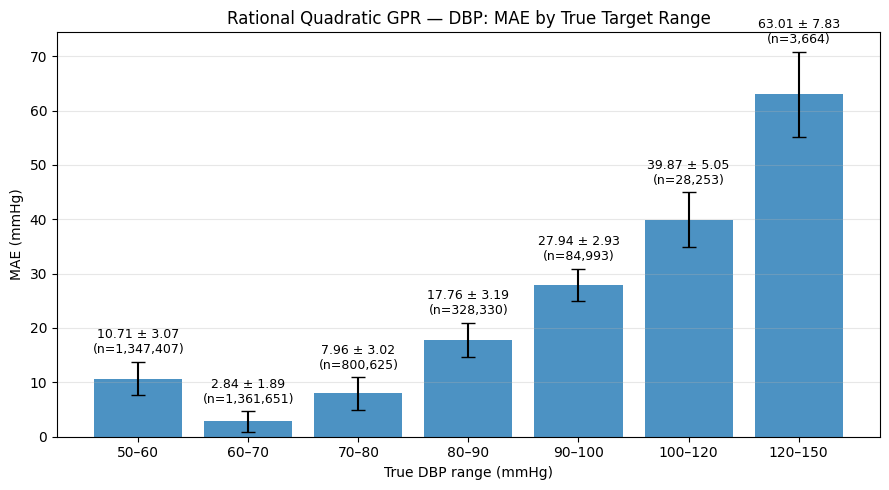

In [13]:
y_pred_vitaldb = predict_gpr_in_batches(
    rq_model,
    X_test_vital,
    y_test_vital,
    target_name=TARGET,
    model_name="Rational Quadratic GPR",
    batch_size=10000
)

## ANN ##

ANN training samples: 5,000

Starting ANN / MLP GridSearch...
Fitting 3 folds for each of 36 candidates, totalling 108 fits


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum i


Best parameters:
{'activation': 'relu', 'alpha': 0.001, 'batch_size': 256, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}

Best CV RMSE: 9.993763060769997

Best ANN / MLP model:
MLPRegressor(alpha=0.001, batch_size=256, early_stopping=True,
             hidden_layer_sizes=(128, 64), max_iter=300, n_iter_no_change=20,
             random_state=42)

Starting batched prediction on 52,863 samples...
Processed 10,000 / 52,863
Processed 20,000 / 52,863
Processed 30,000 / 52,863
Processed 40,000 / 52,863
Processed 50,000 / 52,863
Processed 52,863 / 52,863

ANN / MLP Regressor — DBP
------------------------------------
RMSE: 10.3552
MSE : 107.2309
R²  : 0.1437
MAE : 7.9603


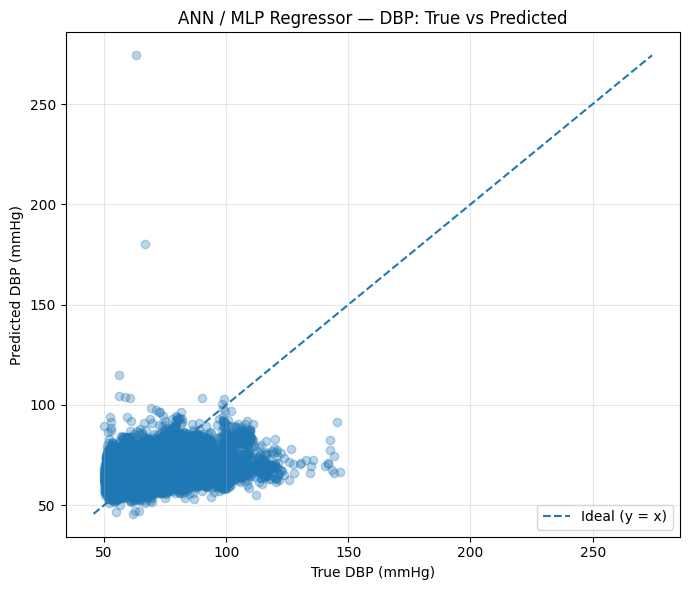

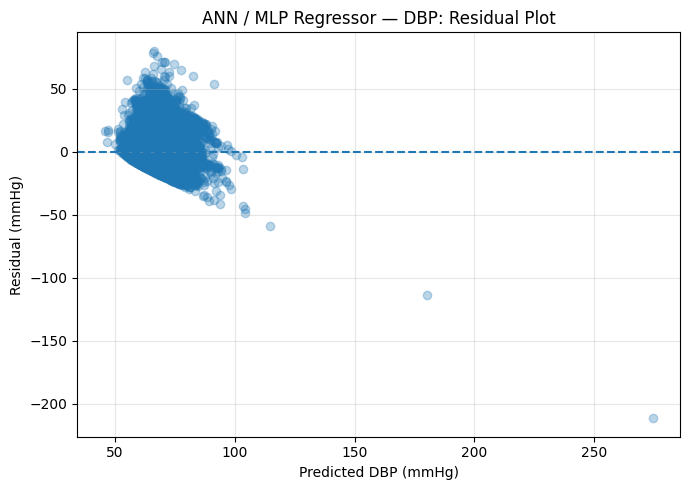

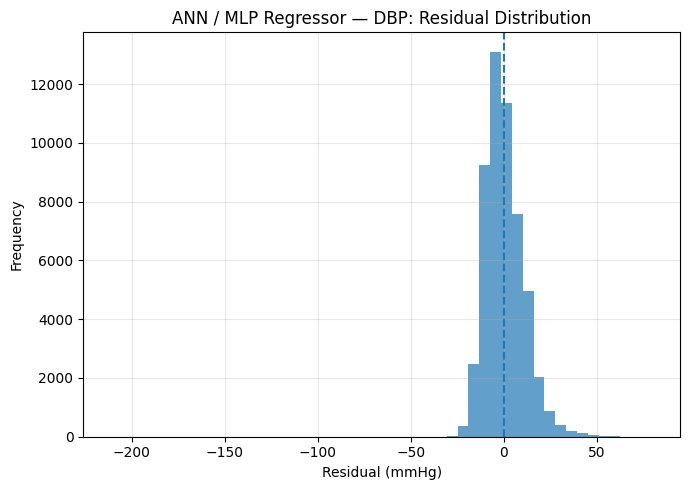

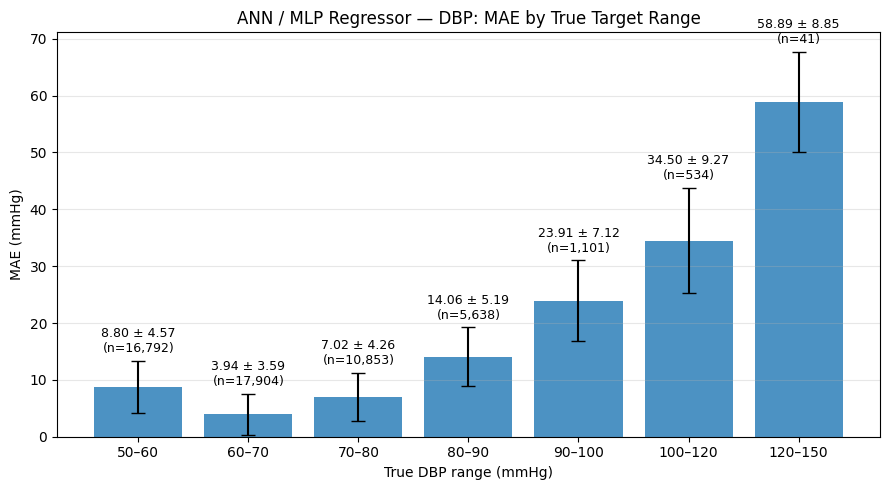

In [14]:
ann_model, y_test_pred = ann(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

Processed 10,000 / 4,651,395
Processed 20,000 / 4,651,395
Processed 30,000 / 4,651,395
Processed 40,000 / 4,651,395
Processed 50,000 / 4,651,395
Processed 60,000 / 4,651,395
Processed 70,000 / 4,651,395
Processed 80,000 / 4,651,395
Processed 90,000 / 4,651,395
Processed 100,000 / 4,651,395
Processed 110,000 / 4,651,395
Processed 120,000 / 4,651,395
Processed 130,000 / 4,651,395
Processed 140,000 / 4,651,395
Processed 150,000 / 4,651,395
Processed 160,000 / 4,651,395
Processed 170,000 / 4,651,395
Processed 180,000 / 4,651,395
Processed 190,000 / 4,651,395
Processed 200,000 / 4,651,395
Processed 210,000 / 4,651,395
Processed 220,000 / 4,651,395
Processed 230,000 / 4,651,395
Processed 240,000 / 4,651,395
Processed 250,000 / 4,651,395
Processed 260,000 / 4,651,395
Processed 270,000 / 4,651,395
Processed 280,000 / 4,651,395
Processed 290,000 / 4,651,395
Processed 300,000 / 4,651,395
Processed 310,000 / 4,651,395
Processed 320,000 / 4,651,395
Processed 330,000 / 4,651,395
Processed 340,000 /

/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_0overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


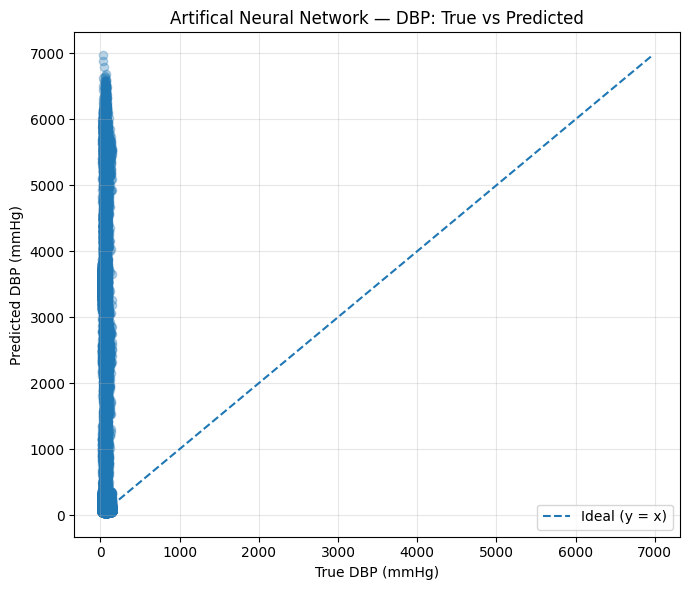

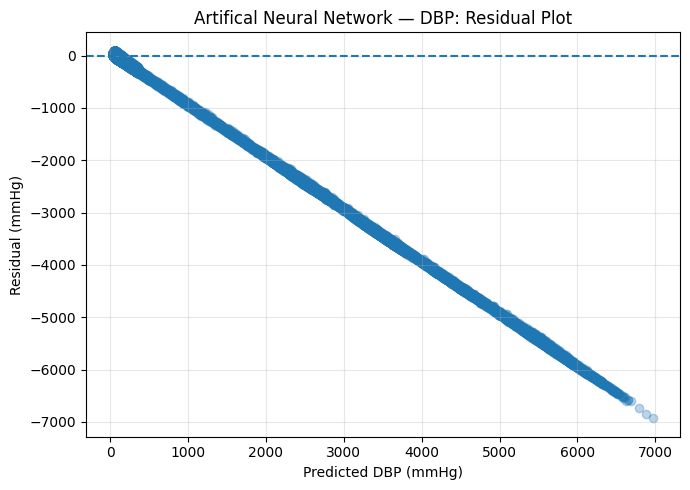

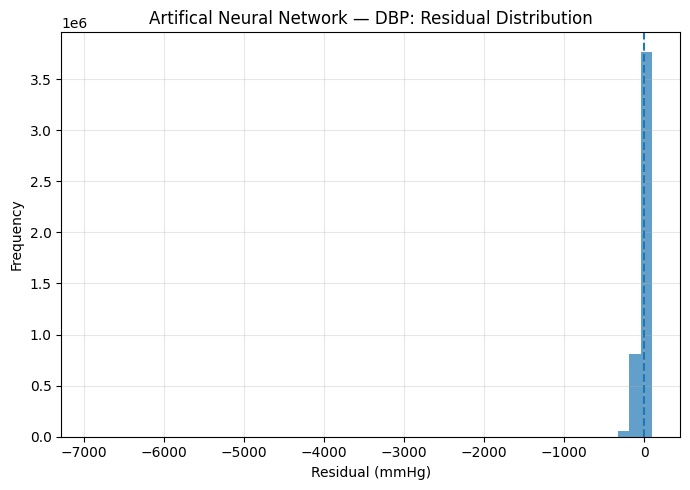

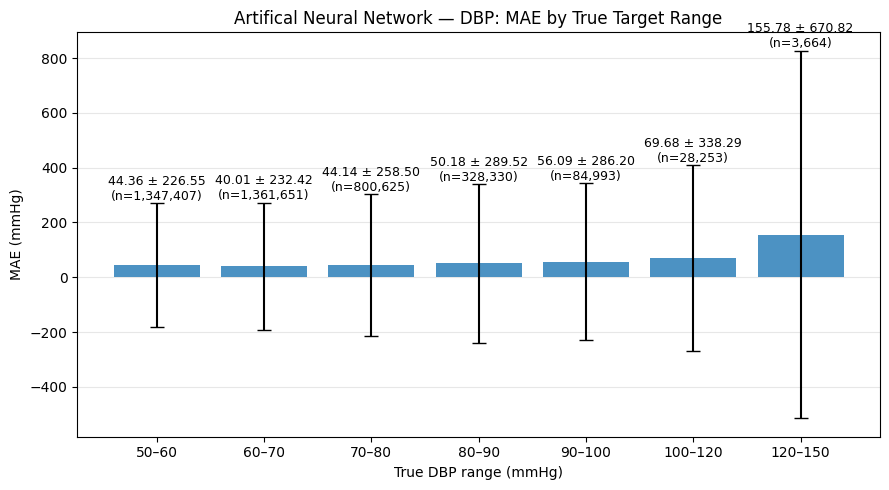

In [15]:
y_pred_vitaldb = predict_ann_in_batches(
    ann_model,
    X_test_vital,
y_test_vital,
    target_name=TARGET,
    model_name="Artifical Neural Network",
    batch_size=10000
)